# Exploratory Data Analysis — Student Performance (Mathematics)



## Purpose

This notebook covers the **EDA responsibility only**. The objective is to understand the structure, quality, distributions, relationships, and risk-target implications in the Mathematics student-performance dataset before downstream preprocessing and model development.

The project document defines the business focus as **At Risk Student Identification**. It states that the final Mathematics grade `G3` is used to construct the `Risk Status` target, while `G3` must not be used as a predictor in the eventual classification model. 

### EDA questions

1. What does the dataset contain and what are the variable types?
2. Are there missing, duplicate, inconsistent, or suspicious observations?
3. What are the distributions of the important academic, demographic, behavioural, and social variables?
4. How are `G1`, `G2`, and `G3` distributed?
5. How does the choice of a risk threshold change the target-class balance?
6. Which variables appear associated with final Mathematics performance?
7. What patterns distinguish students below candidate risk thresholds?
8. What evidence should be passed to data preparation and model development?

> **Important:** EDA may use `G3` to study the outcome and justify a risk threshold. It is **not** treated as a model input here. The project document explicitly warns that including `G3` as a predictor would cause target leakage. 

In [1]:
# ============================================================
# 1. Imports and plotting configuration
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, pointbiserialr, chi2_contingency

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# ============================================================
# 2. Load the Mathematics dataset
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# Update the path below if you placed student-mat.csv in a subfolder.
# Default assumes the file is in the root of My Drive.
DATA_PATH = '/content/drive/My Drive/student-mat.csv'

# UCI's student-mat.csv is semicolon-separated.
df = pd.read_csv(DATA_PATH, sep=';')

print(f'Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns')
df.head()

Mounted at /content/drive
Dataset shape: 395 rows x 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


## 1. Dataset overview

The actual file contains **395 student records and 33 variables**. Each row represents one student, matching the project document's stated unit of analysis. 

The dataset contains academic, demographic, social, and behavioural information. The three Mathematics grades are particularly important:

- `G1` — first-period Mathematics grade
- `G2` — second-period Mathematics grade
- `G3` — final Mathematics grade

The project uses earlier information to predict a risk category associated with the final grade. fileciteturn0file0L161-L173

In [3]:
# ============================================================
# 3. Structural inspection
# ============================================================
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes.to_frame("dtype"))

print("\nDataset information:")
df.info()

Shape: (395, 33)

Data types:
             dtype
school      object
sex         object
age          int64
address     object
famsize     object
Pstatus     object
Medu         int64
Fedu         int64
Mjob        object
Fjob        object
reason      object
guardian    object
traveltime   int64
studytime    int64
failures     int64
schoolsup   object
famsup      object
paid        object
activities  object
nursery     object
higher      object
internet    object
romantic    object
famrel       int64
freetime     int64
goout        int64
Dalc         int64
Walc         int64
health       int64
absences     int64
G1           int64
G2           int64
G3           int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int6

In [4]:
# Variable-level summary: type, unique values, missingness
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "missing": df.isna().sum(),
    "missing_%": df.isna().mean().mul(100).round(2)
}).sort_values(["dtype", "n_unique"])

print(overview)

             dtype  n_unique  missing  missing_%
traveltime   int64         4        0        0.0
studytime    int64         4        0        0.0
failures     int64         4        0        0.0
Medu         int64         5        0        0.0
Fedu         int64         5        0        0.0
famrel       int64         5        0        0.0
freetime     int64         5        0        0.0
goout        int64         5        0        0.0
Dalc         int64         5        0        0.0
Walc         int64         5        0        0.0
health       int64         5        0        0.0
age          int64         8        0        0.0
G1           int64        17        0        0.0
G2           int64        17        0        0.0
G3           int64        18        0        0.0
absences     int64        34        0        0.0
school      object         2        0        0.0
sex         object         2        0        0.0
address     object         2        0        0.0
famsize     object  

### Why this EDA matters

This establishes the schema before any transformation. In particular, it prevents us from treating every variable as continuous: several variables are categorical or ordered rating variables and need different downstream handling.

The project document also says the exact predictor set should only be finalized after EDA, feature analysis, preprocessing, and checking whether variables are available at prediction time.

## 2. Data quality assessment

The first quality checks are missing values, duplicate records, and basic value validity. We should not remove observations merely because they look unusual; an unusual student can be a legitimate observation.

In [5]:
# ============================================================
# 4. Missing values and duplicates
# ============================================================
missing = df.isna().sum().sort_values(ascending=False)
print("Total missing cells:", int(df.isna().sum().sum()))
print(missing[missing > 0].to_frame("missing_count"))

print("Exact duplicate rows:", int(df.duplicated().sum()))

Total missing cells: 0
Empty DataFrame
Columns: [missing_count]
Index: []
Exact duplicate rows: 0


In [6]:
# ============================================================
# 5. Categorical value inspection
# ============================================================
for col in df.select_dtypes(include="object").columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).to_frame("count"))


--- school ---
        count
school       
GP        349
MS         46

--- sex ---
     count
sex       
F      208
M      187

--- address ---
         count
address       
U          307
R           88

--- famsize ---
         count
famsize       
GT3        281
LE3        114

--- Pstatus ---
         count
Pstatus       
T          354
A           41

--- Mjob ---
          count
Mjob           
other       141
services    103
at_home      59
teacher      58
health       34

--- Fjob ---
          count
Fjob           
other       217
services    111
teacher      29
at_home      20
health       18

--- reason ---
            count
reason           
course        145
home          109
reputation    105
other          36

--- guardian ---
          count
guardian       
mother      273
father       90
other        32

--- schoolsup ---
           count
schoolsup       
no           344
yes           51

--- famsup ---
        count
famsup       
yes       242
no        153

--- pa

### Quality finding

The notebook should report the executed result rather than assuming a problem exists. For this file, the initial inspection shows **no missing cells and no exact duplicate rows**. Therefore, there is no evidence here requiring blanket imputation or duplicate deletion.

Categorical-value inspection is still necessary because inconsistent spelling/casing or unexpected categories can silently create extra levels.

In [7]:
# ============================================================
# 6. Domain/range checks for numeric variables
# ============================================================
expected_ranges = {
    "age": (15, 22),
    "Medu": (0, 4),
    "Fedu": (0, 4),
    "traveltime": (1, 4),
    "studytime": (1, 4),
    "failures": (0, 3),
    "famrel": (1, 5),
    "freetime": (1, 5),
    "goout": (1, 5),
    "Dalc": (1, 5),
    "Walc": (1, 5),
    "health": (1, 5),
    "absences": (0, np.inf),
    "G1": (0, 20),
    "G2": (0, 20),
    "G3": (0, 20),
}

range_results = []
for col, (low, high) in expected_ranges.items():
    if col in df.columns:
        invalid = ((df[col] < low) | (df[col] > high)).sum()
        range_results.append({
            "variable": col,
            "expected_min": low,
            "expected_max": high,
            "observed_min": df[col].min(),
            "observed_max": df[col].max(),
            "invalid_count": int(invalid)
        })

range_check = pd.DataFrame(range_results)
print(range_check)

      variable  expected_min  expected_max  observed_min  observed_max  \
0          age            15          22.0            15            22   
1         Medu             0           4.0             0             4   
2         Fedu             0           4.0             0             4   
3   traveltime             1           4.0             1             4   
4    studytime             1           4.0             1             4   
5     failures             0           3.0             0             3   
6       famrel             1           5.0             1             5   
7     freetime             1           5.0             1             5   
8        goout             1           5.0             1             5   
9         Dalc             1           5.0             1             5   
10        Walc             1           5.0             1             5   
11      health             1           5.0             1             5   
12    absences             0          

### Interpretation of range checks

Range validation is preferable to deleting outliers automatically. For example, `absences` can legitimately be much larger than the typical student value. An extreme value should only be removed if there is evidence that it is erroneous.

This distinction is important because the dataset is relatively small; unnecessary deletion can remove real information.

# 3. Descriptive statistics

We now summarize the numerical variables and inspect the shape of important distributions. Descriptive statistics help identify central tendency, spread, skewness, and possible unusual values before modelling.

In [8]:
# ============================================================
# 7. Descriptive statistics
# ============================================================
print(df.describe().T.round(2))

            count   mean   std   min   25%   50%   75%   max
age         395.0  16.70  1.28  15.0  16.0  17.0  18.0  22.0
Medu        395.0   2.75  1.09   0.0   2.0   3.0   4.0   4.0
Fedu        395.0   2.52  1.09   0.0   2.0   2.0   3.0   4.0
traveltime  395.0   1.45  0.70   1.0   1.0   1.0   2.0   4.0
studytime   395.0   2.04  0.84   1.0   1.0   2.0   2.0   4.0
failures    395.0   0.33  0.74   0.0   0.0   0.0   0.0   3.0
famrel      395.0   3.94  0.90   1.0   4.0   4.0   5.0   5.0
freetime    395.0   3.24  1.00   1.0   3.0   3.0   4.0   5.0
goout       395.0   3.11  1.11   1.0   2.0   3.0   4.0   5.0
Dalc        395.0   1.48  0.89   1.0   1.0   1.0   2.0   5.0
Walc        395.0   2.29  1.29   1.0   1.0   2.0   3.0   5.0
health      395.0   3.55  1.39   1.0   3.0   4.0   5.0   5.0
absences    395.0   5.71  8.00   0.0   0.0   4.0   8.0  75.0
G1          395.0  10.91  3.32   3.0   8.0  11.0  13.0  19.0
G2          395.0  10.71  3.76   0.0   9.0  11.0  13.0  19.0
G3          395.0  10.42

In [9]:
# ============================================================
# 8. Skewness analysis
# ============================================================
numeric_skew = (
    df.select_dtypes(include=np.number)
      .skew()
      .sort_values(key=lambda s: s.abs(), ascending=False)
      .to_frame("skewness")
)

print(numeric_skew.round(3))

            skewness
absences       3.672
failures       2.387
Dalc           2.191
traveltime     1.607
famrel        -0.952
G3            -0.733
studytime      0.632
Walc           0.612
health        -0.495
age            0.466
G2            -0.432
Medu          -0.318
G1             0.241
freetime      -0.163
goout          0.117
Fedu          -0.032


### Why skewness matters

Strongly skewed variables can influence statistical summaries and some modelling approaches. `absences` is especially worth inspecting because attendance counts are non-negative and may have a long right tail.

We should **inspect** skewness rather than automatically log-transforming or clipping every skewed feature. The transformation decision belongs to preprocessing/model development and should be evaluated using the training data.

# 4. Univariate EDA — numerical and ordinal variables

Histograms show the empirical distribution, while boxplots help reveal spread and potential extreme observations. These plots are useful for identifying variables that may need special consideration downstream.

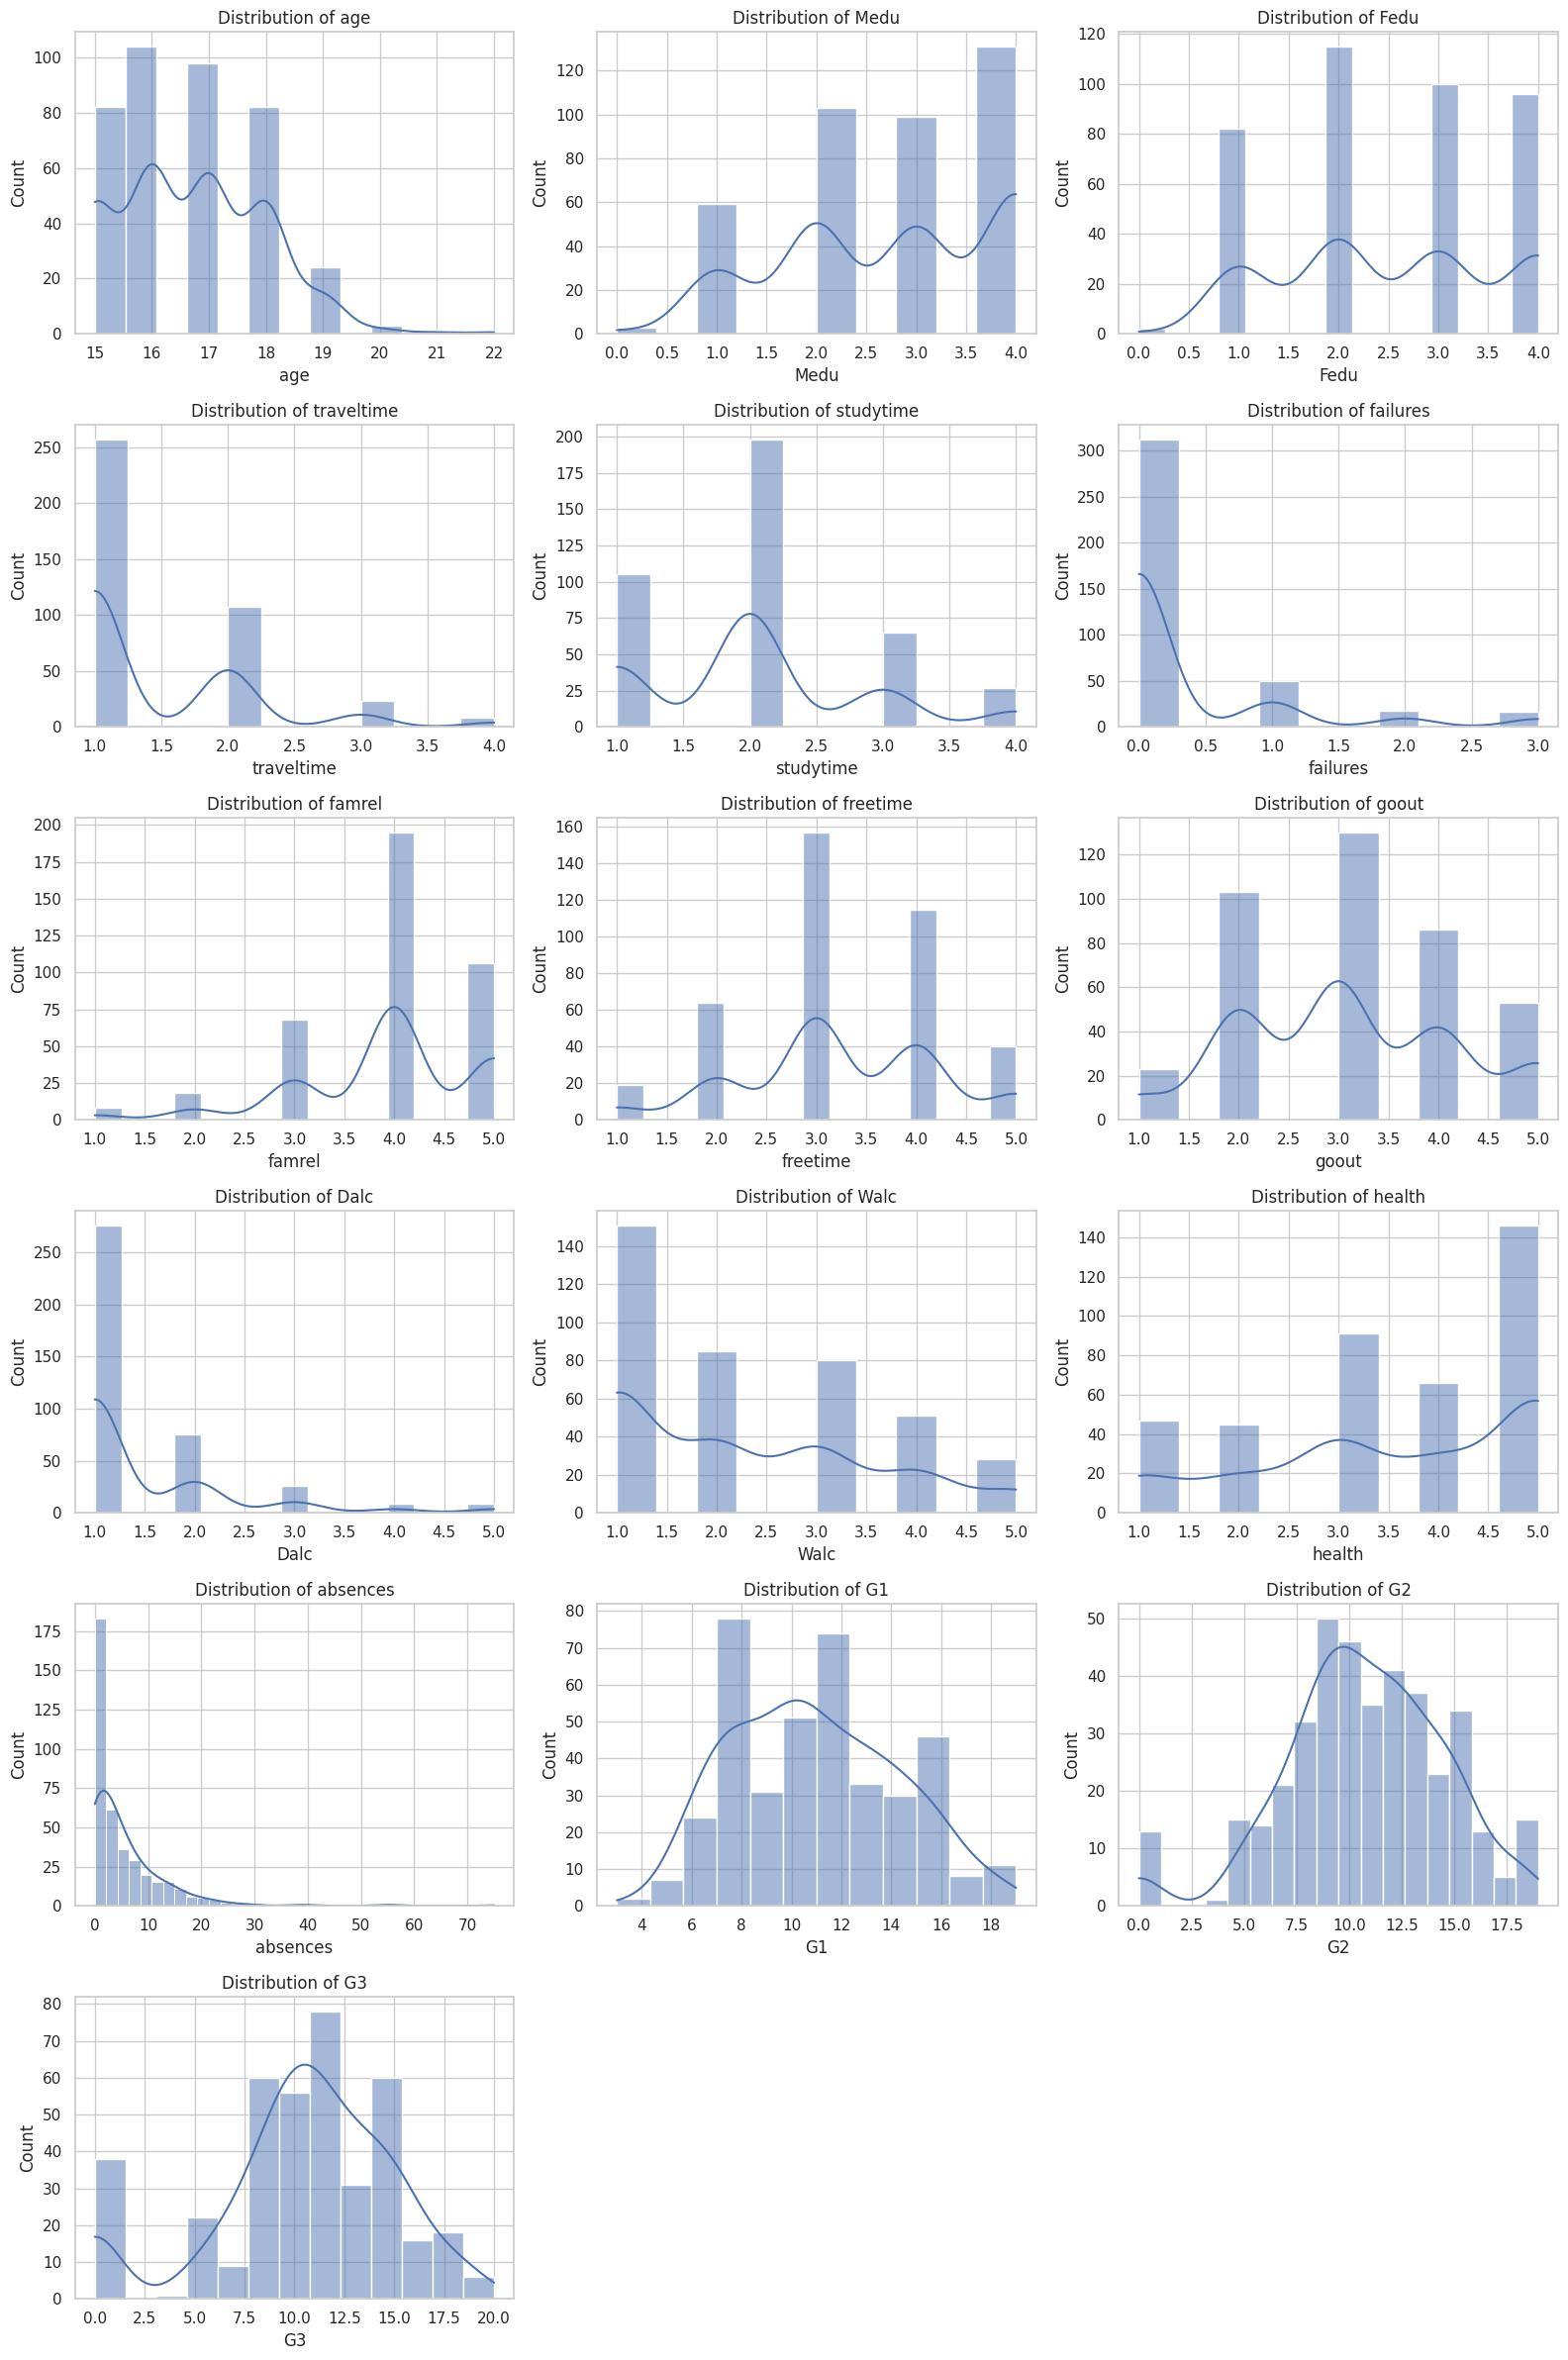

In [10]:
# ============================================================
# 9. Histograms for all numerical variables
# ============================================================
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

ncols = 3
nrows = int(np.ceil(len(numeric_cols) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)

for ax in axes[len(numeric_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

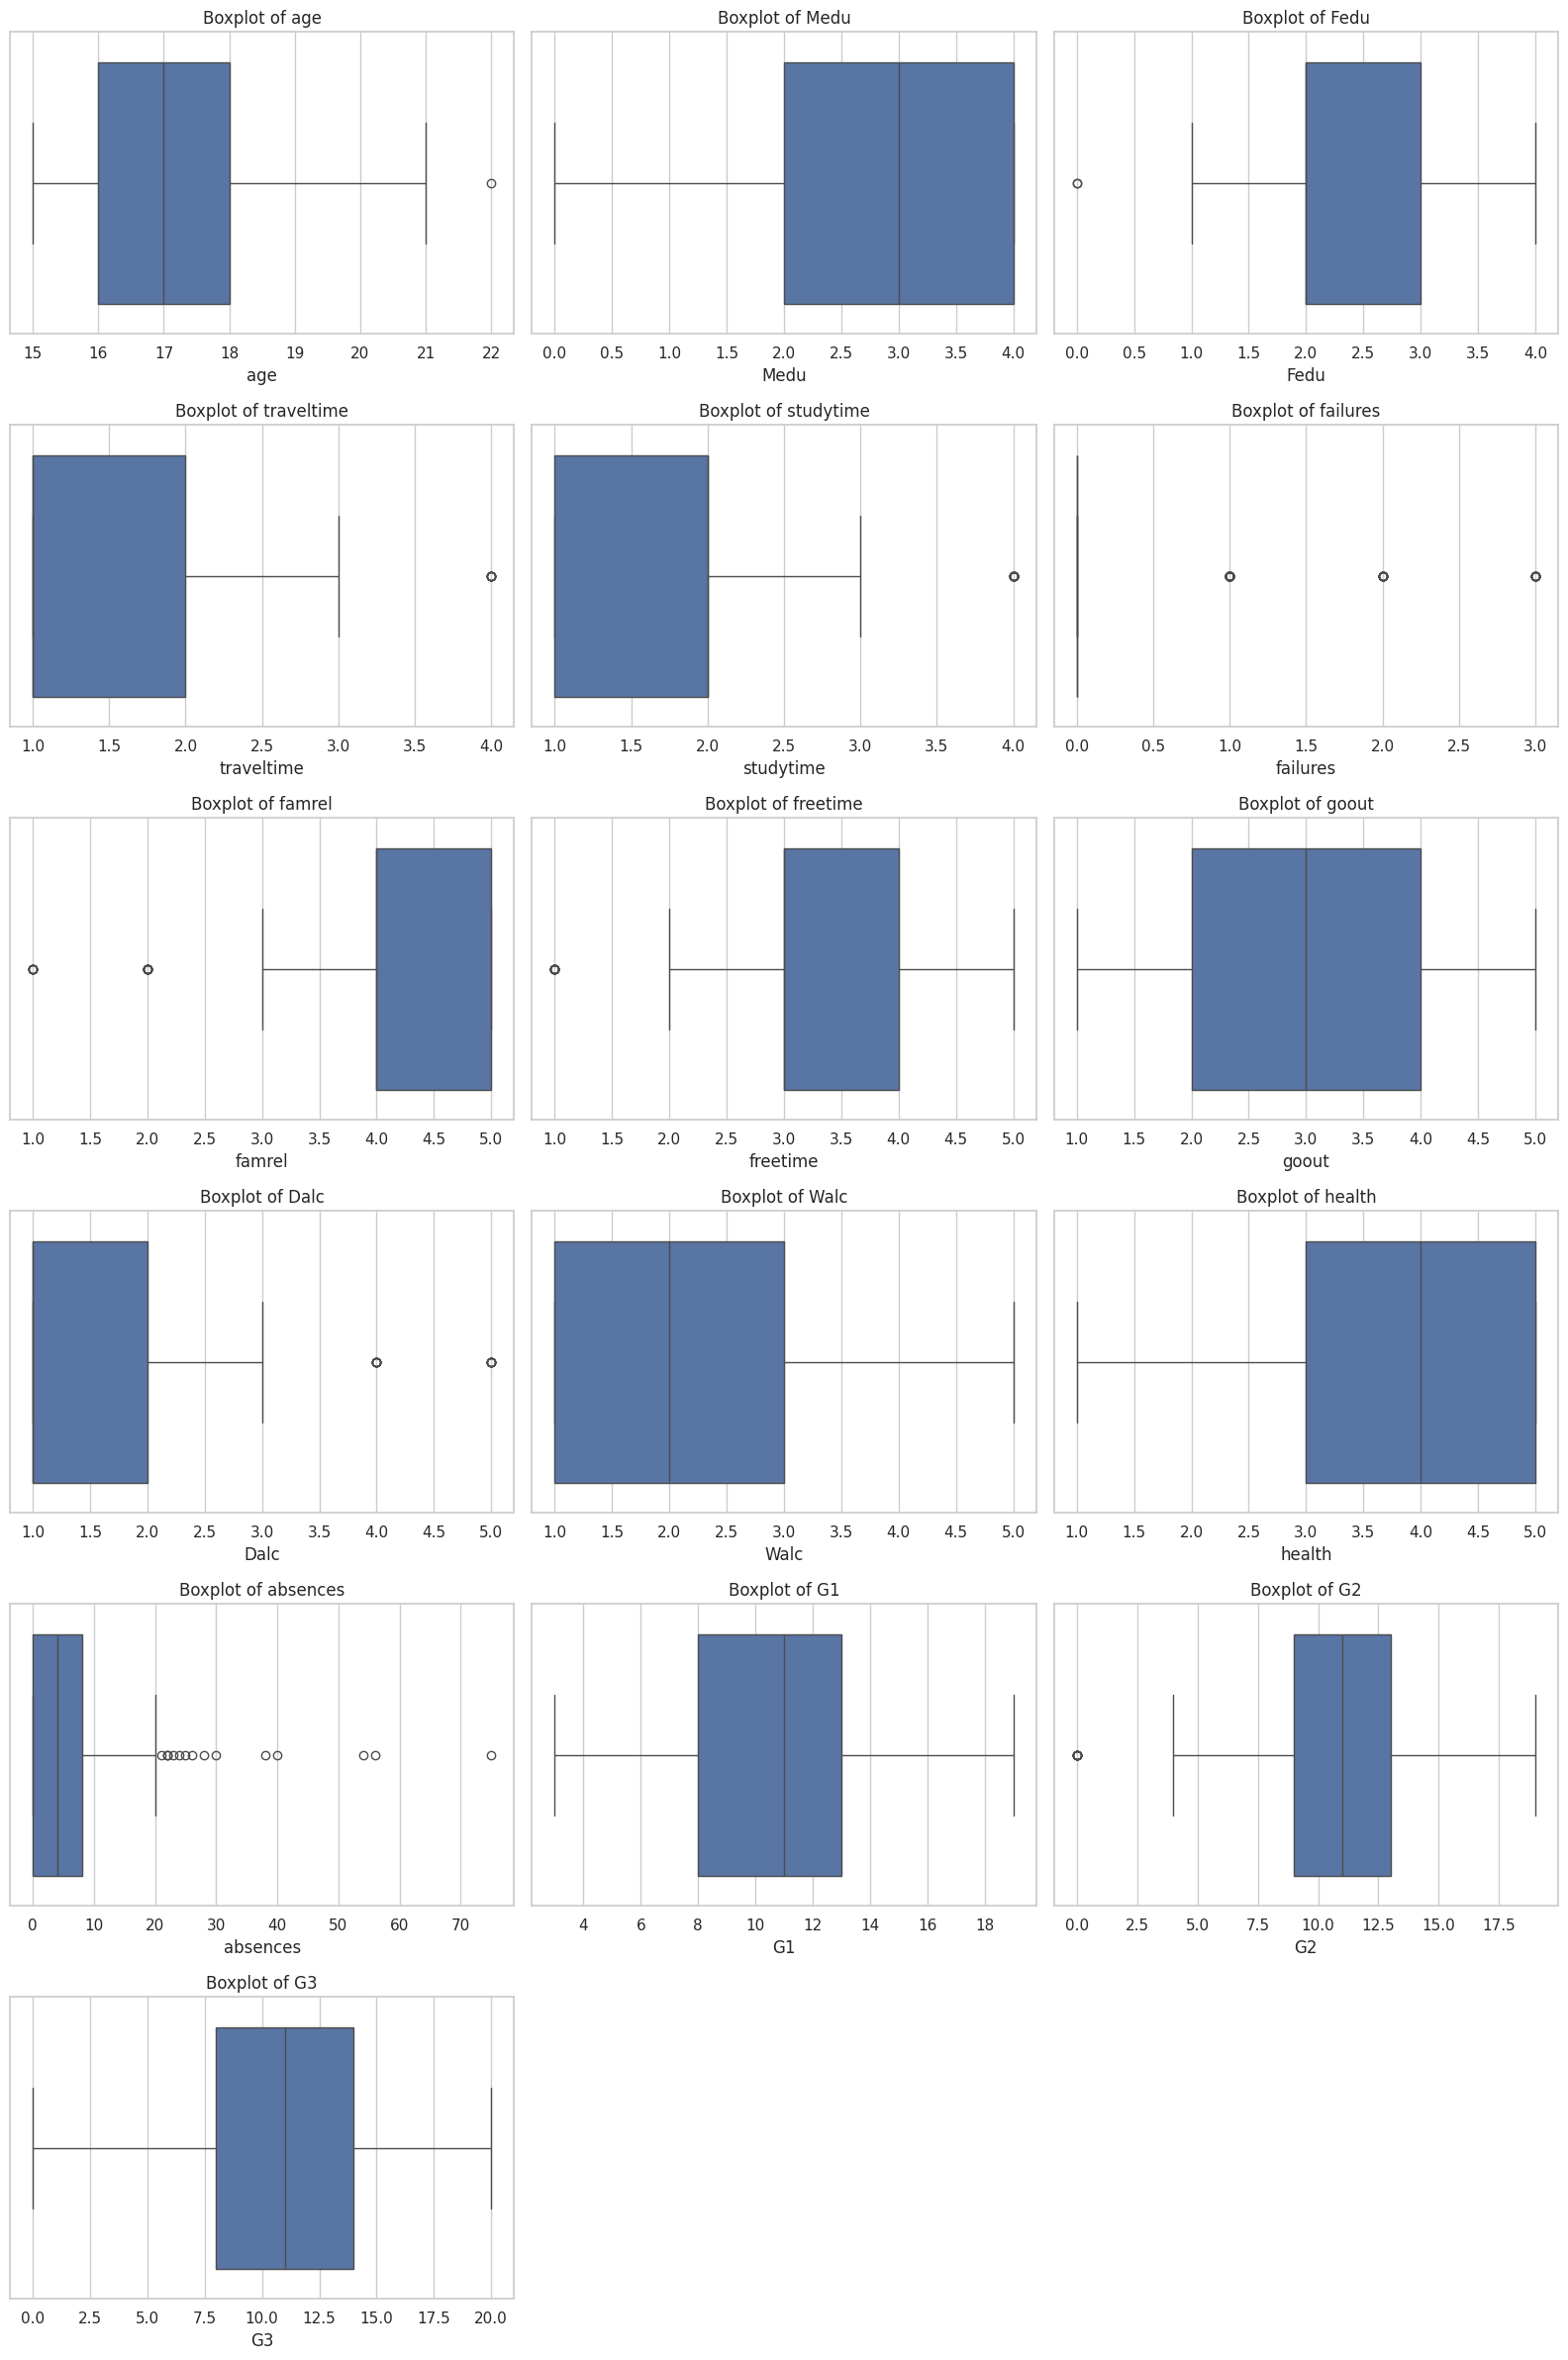

In [11]:
# ============================================================
# 10. Boxplots for numerical variables
# ============================================================
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(f"Boxplot of {col}")
    ax.set_xlabel(col)

for ax in axes[len(numeric_cols):]:
    ax.remove()

plt.tight_layout()
plt.show()

### Interpretation guidance

- Concentrated ordinal variables are expected because many are ratings on short scales.
- `G1`, `G2`, and `G3` deserve special attention because they represent sequential academic performance.
- `absences` should be checked for right-skew and extreme but potentially legitimate observations.

# 5. Univariate EDA — categorical variables

Frequency plots show the composition of the student population for categorical attributes. These are important because an apparently strong relationship can be misleading when a category has very few observations.


school
        count  percentage
school                   
GP        349       88.35
MS         46       11.65


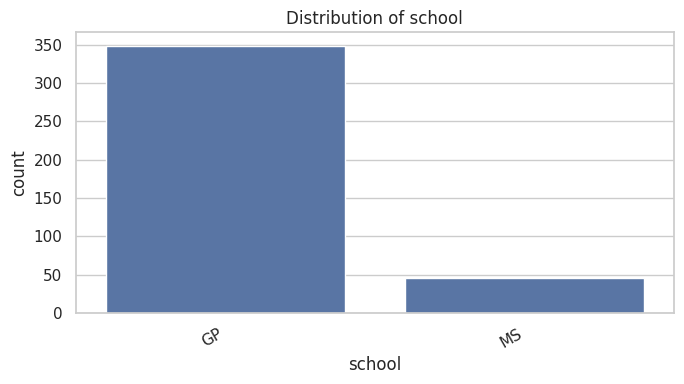


sex
     count  percentage
sex                   
F      208       52.66
M      187       47.34


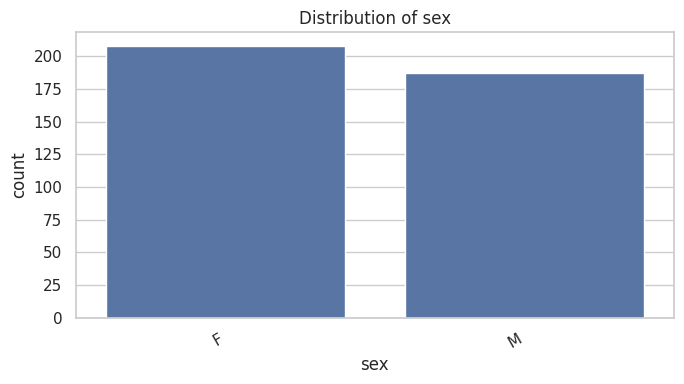


address
         count  percentage
address                   
U          307       77.72
R           88       22.28


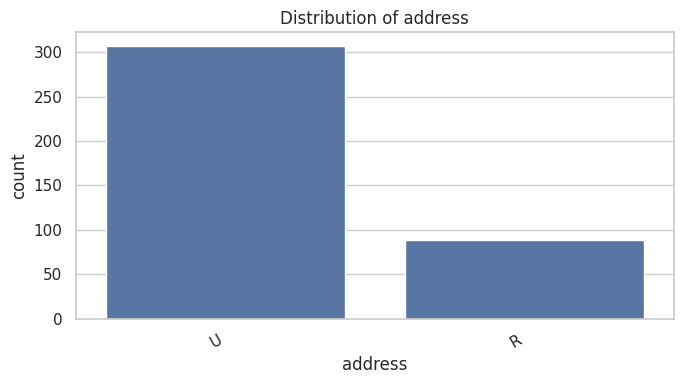


famsize
         count  percentage
famsize                   
GT3        281       71.14
LE3        114       28.86


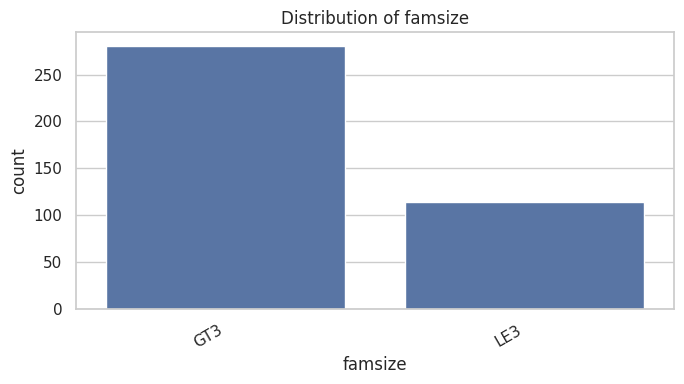


Pstatus
         count  percentage
Pstatus                   
T          354       89.62
A           41       10.38


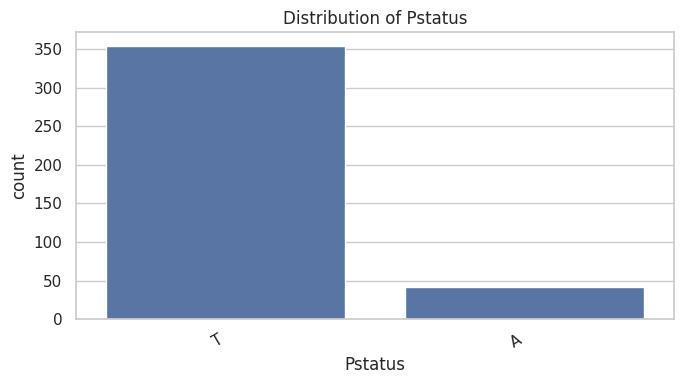


Mjob
          count  percentage
Mjob                       
other       141       35.70
services    103       26.08
at_home      59       14.94
teacher      58       14.68
health       34        8.61


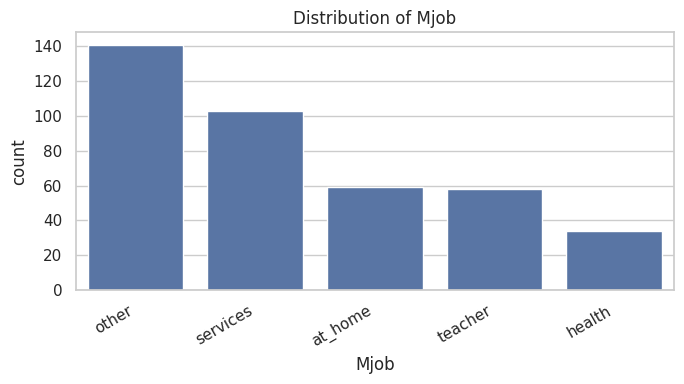


Fjob
          count  percentage
Fjob                       
other       217       54.94
services    111       28.10
teacher      29        7.34
at_home      20        5.06
health       18        4.56


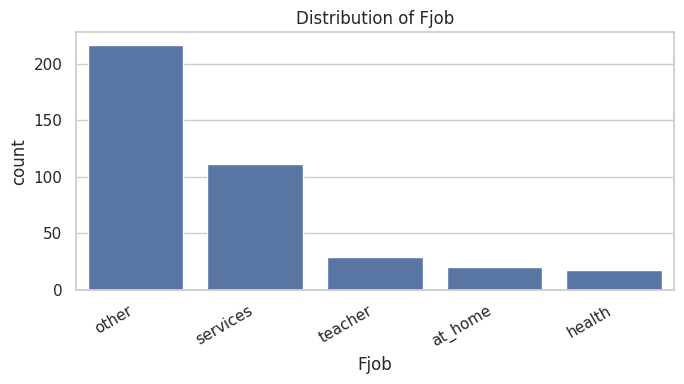


reason
            count  percentage
reason                       
course        145       36.71
home          109       27.59
reputation    105       26.58
other          36        9.11


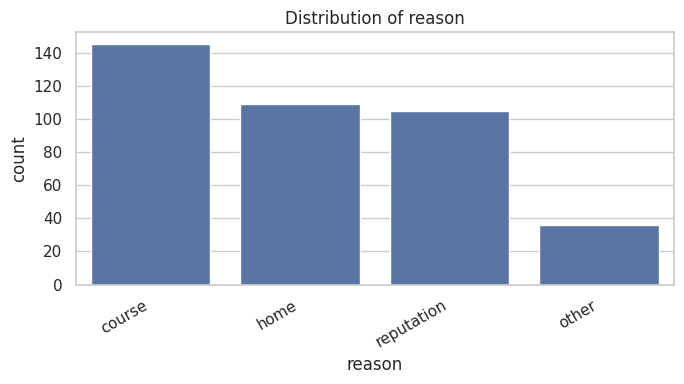


guardian
          count  percentage
guardian                   
mother      273       69.11
father       90       22.78
other        32        8.10


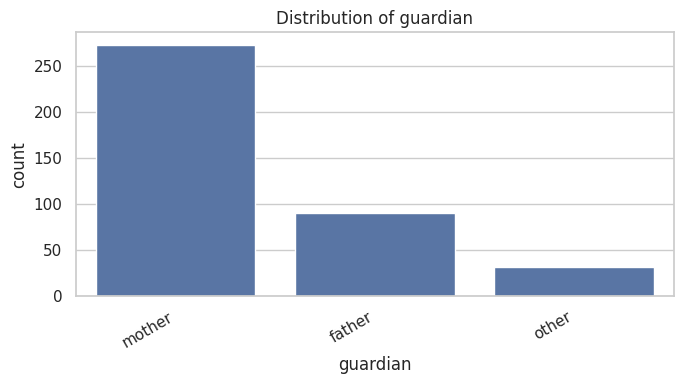


schoolsup
           count  percentage
schoolsup                   
no           344       87.09
yes           51       12.91


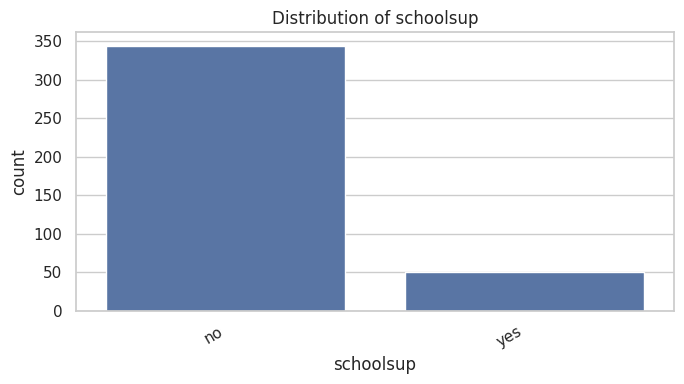


famsup
        count  percentage
famsup                   
yes       242       61.27
no        153       38.73


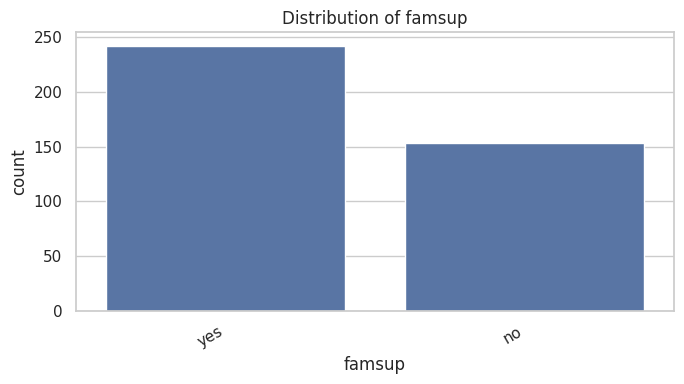


paid
      count  percentage
paid                   
no      214       54.18
yes     181       45.82


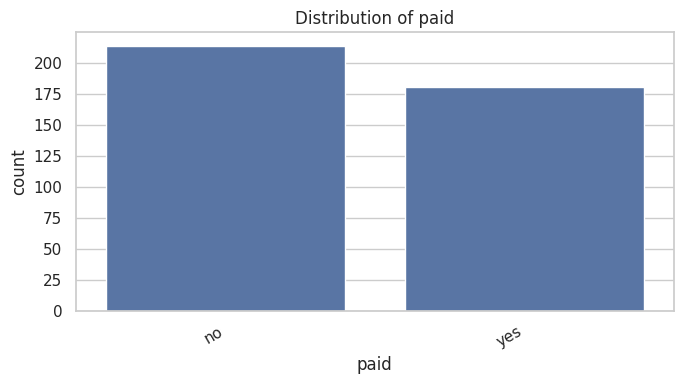


activities
            count  percentage
activities                   
yes           201       50.89
no            194       49.11


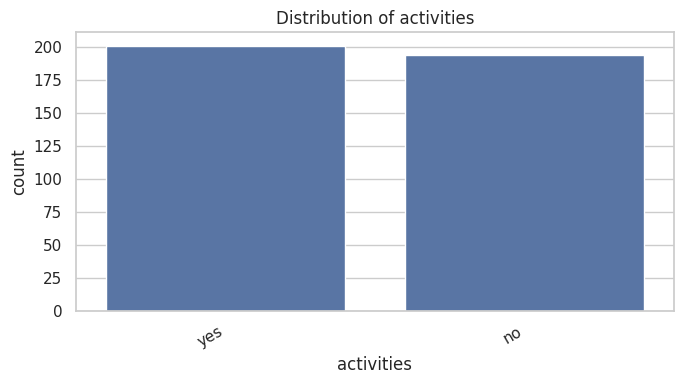


nursery
         count  percentage
nursery                   
yes        314       79.49
no          81       20.51


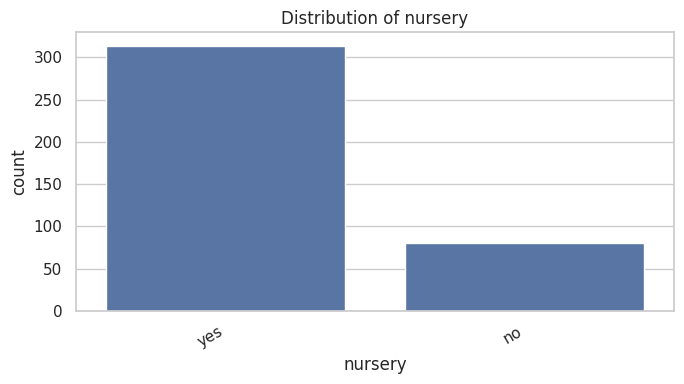


higher
        count  percentage
higher                   
yes       375       94.94
no         20        5.06


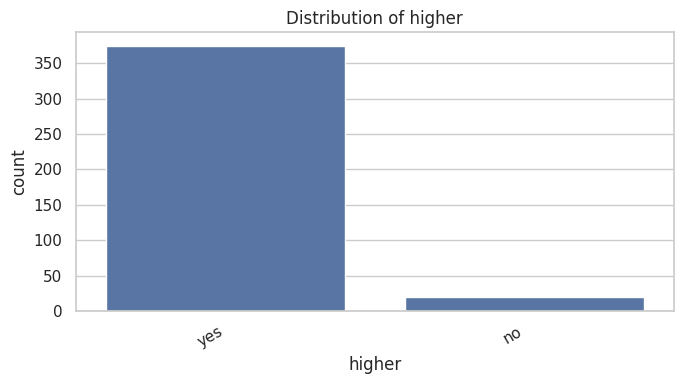


internet
          count  percentage
internet                   
yes         329       83.29
no           66       16.71


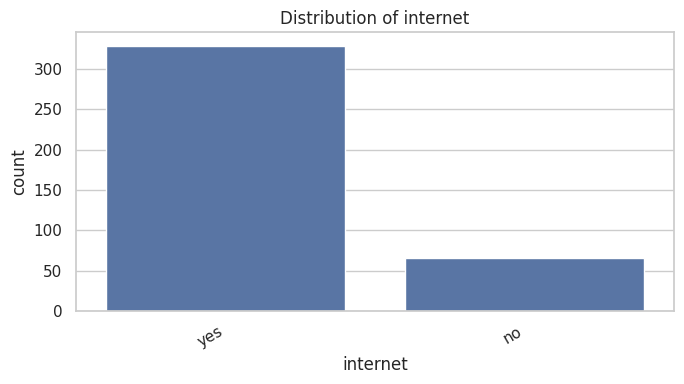


romantic
          count  percentage
romantic                   
no          263       66.58
yes         132       33.42


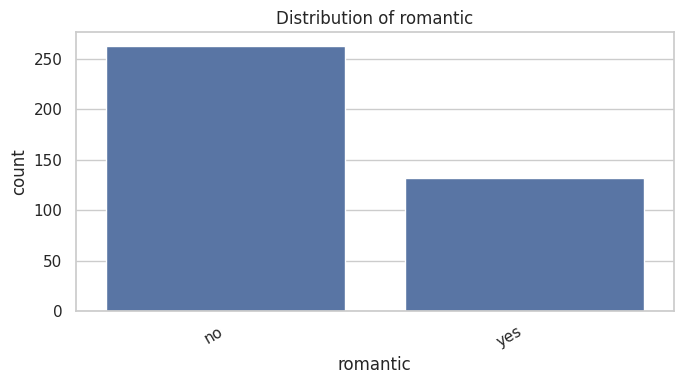

In [12]:
# ============================================================
# 11. Frequency tables and plots for categorical variables
# ============================================================
categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    counts = df[col].value_counts(dropna=False)
    print(f"\n{col}")
    print(pd.DataFrame({
        "count": counts,
        "percentage": (counts / len(df) * 100).round(2)
    }))

    plt.figure(figsize=(7, 4))
    sns.countplot(data=df, x=col, order=counts.index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

### What to look for

For each categorical feature, look for:

- dominant versus minority categories;
- categories with very small counts;
- possible imbalance that could make group comparisons unstable.

This is descriptive evidence only; it does not establish causation.

# 6. Academic performance EDA

The business problem is specifically about final Mathematics performance. Therefore, `G1`, `G2`, and `G3` receive dedicated analysis.

The project document defines `G1` and `G2` as grades available before the final grade and `G3` as the final Mathematics grade used to define the risk target. 

In [13]:
# ============================================================
# 12. G1, G2, G3 descriptive statistics
# ============================================================
grades = ["G1", "G2", "G3"]

grade_summary = df[grades].agg(
    ["count", "mean", "median", "std", "min", "max"]
).T.round(2)

print(grade_summary)

    count   mean  median   std  min   max
G1  395.0  10.91    11.0  3.32  3.0  19.0
G2  395.0  10.71    11.0  3.76  0.0  19.0
G3  395.0  10.42    11.0  4.58  0.0  20.0


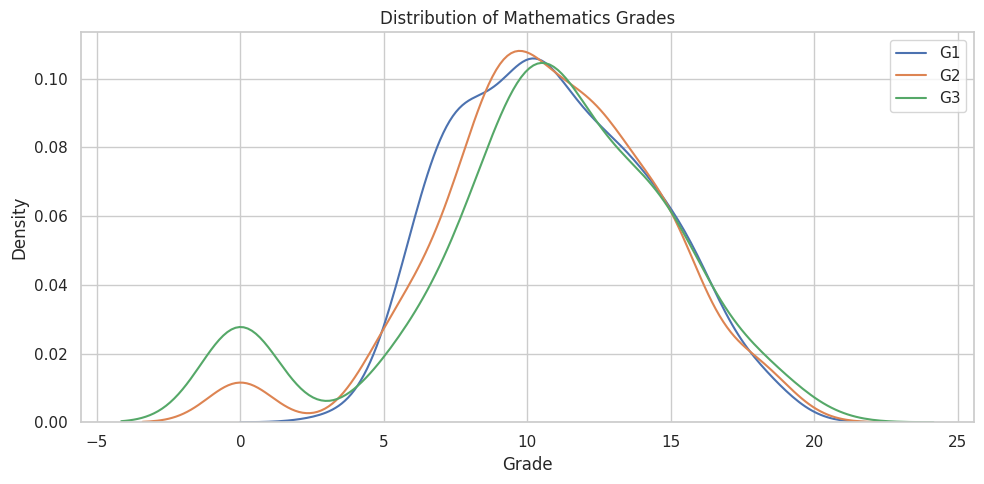

In [14]:
# ============================================================
# 13. Grade distributions
# ============================================================
plt.figure(figsize=(10, 5))
for col in grades:
    sns.kdeplot(df[col], label=col, fill=False)
plt.title("Distribution of Mathematics Grades")
plt.xlabel("Grade")
plt.legend()
plt.tight_layout()
plt.show()

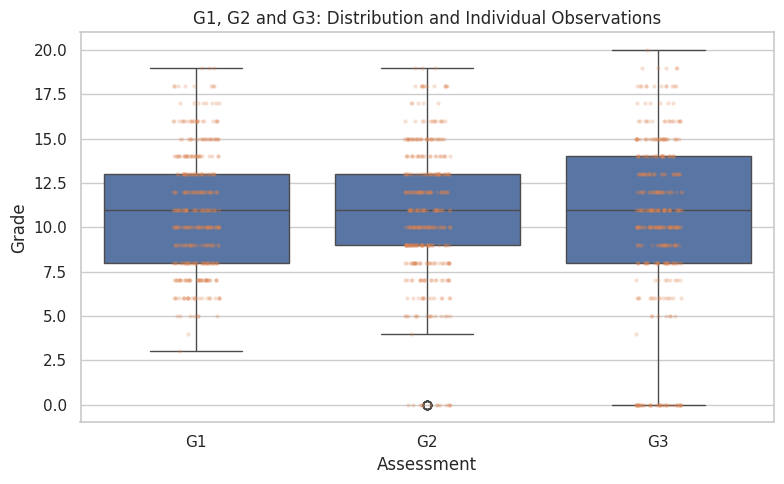

In [15]:
# ============================================================
# 14. Grade-by-grade boxplots
# ============================================================
grade_long = df[grades].melt(var_name="Assessment", value_name="Grade")

plt.figure(figsize=(8, 5))
sns.boxplot(data=grade_long, x="Assessment", y="Grade")
sns.stripplot(data=grade_long, x="Assessment", y="Grade", alpha=0.25, size=3)
plt.title("G1, G2 and G3: Distribution and Individual Observations")
plt.tight_layout()
plt.show()

## Grade progression

A particularly useful question is whether performance in `G1` and `G2` is associated with `G3`. This directly tests whether earlier academic performance contains useful predictive information, which is central to the project's proposed workflow.

       G1     G2     G3
G1  1.000  0.852  0.801
G2  0.852  1.000  0.905
G3  0.801  0.905  1.000


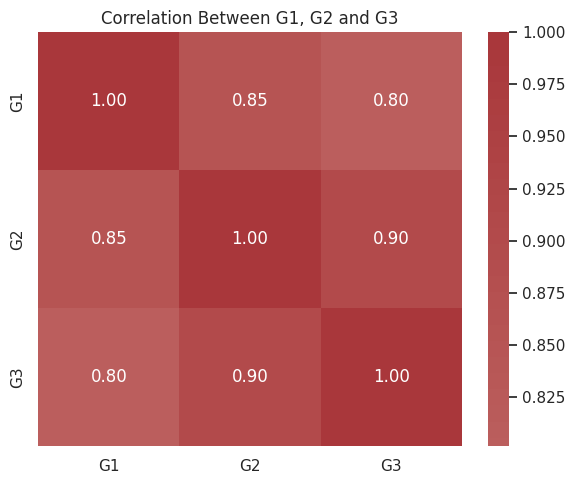

In [16]:
# ============================================================
# 15. Grade correlations
# ============================================================
grade_corr = df[grades].corr()
print(grade_corr.round(3))

plt.figure(figsize=(6, 5))
sns.heatmap(grade_corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Between G1, G2 and G3")
plt.tight_layout()
plt.show()

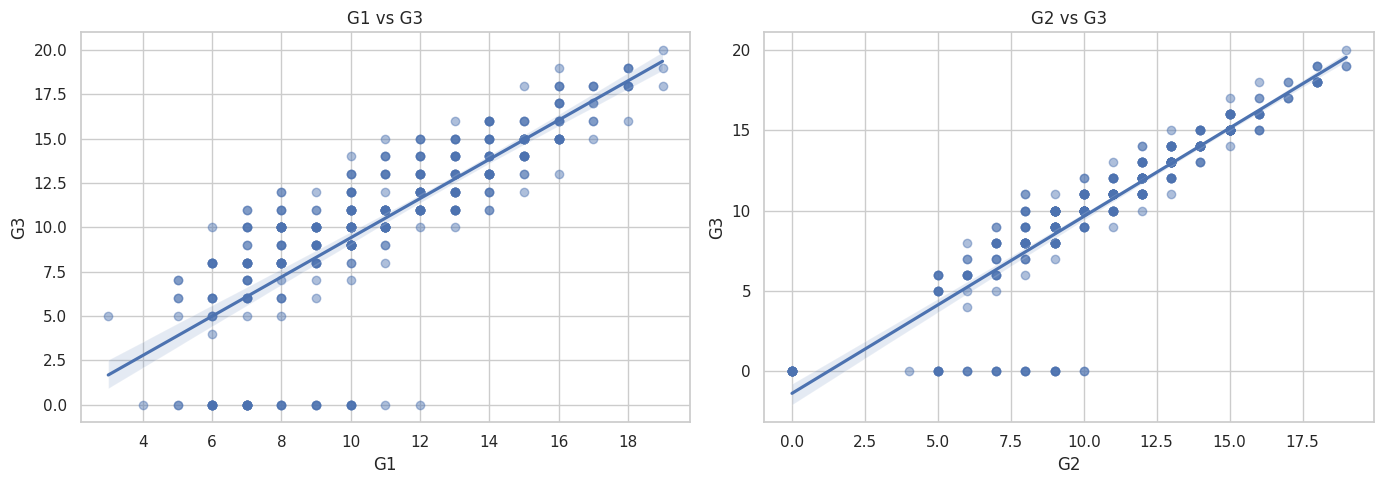

In [17]:
# ============================================================
# 16. G1/G2 against G3
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x="G1", y="G3", ax=axes[0], scatter_kws={"alpha": 0.45})
axes[0].set_title("G1 vs G3")

sns.regplot(data=df, x="G2", y="G3", ax=axes[1], scatter_kws={"alpha": 0.45})
axes[1].set_title("G2 vs G3")

plt.tight_layout()
plt.show()

### Interpretation

Use these plots to determine whether students with stronger earlier grades generally have stronger final grades. Do not interpret the regression line as proof of causation.

The project's own limitation section anticipates that `G1` and `G2` may be very important predictors and that the final model may rely heavily on previous academic performance. 

# 7. Risk-threshold investigation

`Risk Status` is **not an original column** in the UCI dataset. The project requires it to be constructed from `G3` using a risk threshold justified using grading context and EDA. 

We therefore examine multiple plausible thresholds before choosing one. This is an EDA/target-definition exercise, not model fitting.

In [18]:
# ============================================================
# 17. Candidate risk thresholds
# ============================================================
candidate_thresholds = [8, 9, 10, 11, 12]

threshold_analysis = []
for threshold in candidate_thresholds:
    at_risk = (df["G3"] < threshold)
    n_at_risk = int(at_risk.sum())
    n_not_risk = int((~at_risk).sum())

    threshold_analysis.append({
        "Threshold": f"G3 < {threshold}",
        "Threshold_value": threshold,
        "At_Risk_n": n_at_risk,
        "At_Risk_%": round(n_at_risk / len(df) * 100, 2),
        "Not_At_Risk_n": n_not_risk,
        "Not_At_Risk_%": round(n_not_risk / len(df) * 100, 2)
    })

threshold_df = pd.DataFrame(threshold_analysis)
print(threshold_df)

  Threshold  Threshold_value  At_Risk_n  At_Risk_%  Not_At_Risk_n  \
0    G3 < 8                8         70      17.72            325   
1    G3 < 9                9        102      25.82            293   
2   G3 < 10               10        130      32.91            265   
3   G3 < 11               11        186      47.09            209   
4   G3 < 12               12        233      58.99            162   

   Not_At_Risk_%  
0          82.28  
1          74.18  
2          67.09  
3          52.91  
4          41.01  


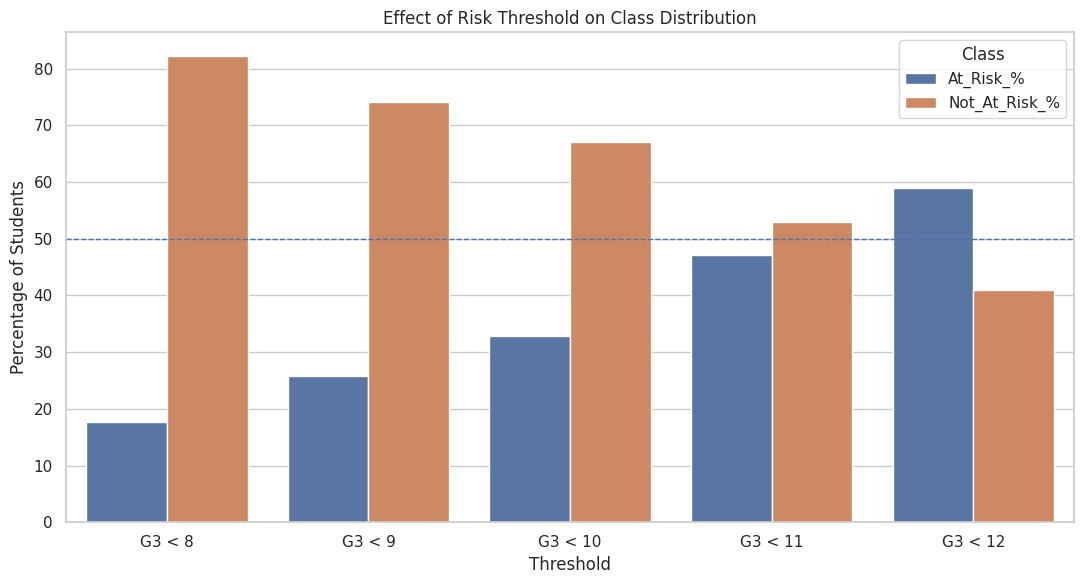

In [19]:
# ============================================================
# 18. Visual comparison of candidate class balances
# ============================================================
plot_df = threshold_df.melt(
    id_vars=["Threshold"],
    value_vars=["At_Risk_%", "Not_At_Risk_%"],
    var_name="Class",
    value_name="Percentage"
)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_df, x="Threshold", y="Percentage", hue="Class")
plt.axhline(50, linestyle="--", linewidth=1)
plt.title("Effect of Risk Threshold on Class Distribution")
plt.ylabel("Percentage of Students")
plt.tight_layout()
plt.show()

### Threshold decision framework

A threshold should not be chosen because it gives the highest model accuracy. It defines the **business meaning of the target itself**.

Evaluate candidate thresholds using:

1. educational/grading interpretation;
2. number of students labelled At Risk;
3. whether the positive class is large enough for meaningful model evaluation;
4. whether the resulting definition matches the project's business objective;
5. evidence from the `G3` distribution.

The project document explicitly states that a different threshold changes the number of At Risk students, class distribution, and potentially model performance. 

## Candidate threshold to carry forward

For this dataset, **G3 < 10** is a strong candidate for further group discussion because it creates a substantial minority At-Risk group rather than an extremely rare class. However, the final report should describe it as an **evidence-based project decision**, not as a universal educational law.

The EDA evidence should be handed to the team member responsible for target preparation before the final target is frozen.

In [20]:
# ============================================================
# 19. Inspect G3 values around the candidate boundary
# ============================================================
g3_distribution = df["G3"].value_counts().sort_index().to_frame("count")
g3_distribution["percentage"] = (g3_distribution["count"] / len(df) * 100).round(2)

print(g3_distribution)

    count  percentage
G3                   
0      38        9.62
4       1        0.25
5       7        1.77
6      15        3.80
7       9        2.28
8      32        8.10
9      28        7.09
10     56       14.18
11     47       11.90
12     31        7.85
13     31        7.85
14     27        6.84
15     33        8.35
16     16        4.05
17      6        1.52
18     12        3.04
19      5        1.27
20      1        0.25


# 8. Bivariate EDA — numerical predictors versus G3

We now investigate whether other numerical/ordinal variables differ across final Mathematics performance.

For ordered variables, boxplots or grouped summaries are often more informative than a raw correlation alone.

            Pearson_correlation_with_G3
G2                                0.905
G1                                0.801
failures                         -0.360
Medu                              0.217
age                              -0.162
Fedu                              0.152
goout                            -0.133
traveltime                       -0.117
studytime                         0.098
health                           -0.061
Dalc                             -0.055
Walc                             -0.052
famrel                            0.051
absences                          0.034
freetime                          0.011


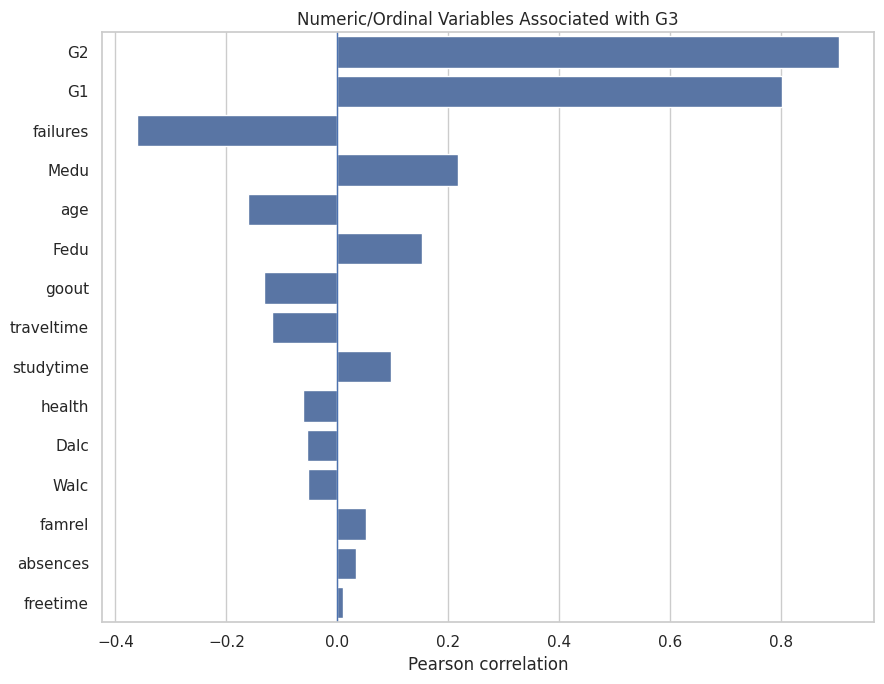

In [21]:
# ============================================================
# 20. Correlation of numeric variables with G3
# ============================================================
corr_with_g3 = (
    df.select_dtypes(include=np.number)
      .corr()["G3"]
      .drop("G3")
      .sort_values(key=lambda s: s.abs(), ascending=False)
)

print(corr_with_g3.to_frame("Pearson_correlation_with_G3").round(3))

plt.figure(figsize=(9, 7))
sns.barplot(
    x=corr_with_g3.values,
    y=corr_with_g3.index
)
plt.axvline(0, linestyle="-", linewidth=1)
plt.title("Numeric/Ordinal Variables Associated with G3")
plt.xlabel("Pearson correlation")
plt.ylabel("")
plt.tight_layout()
plt.show()

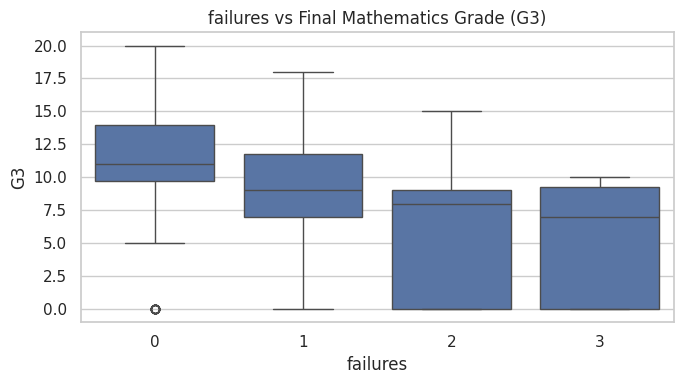

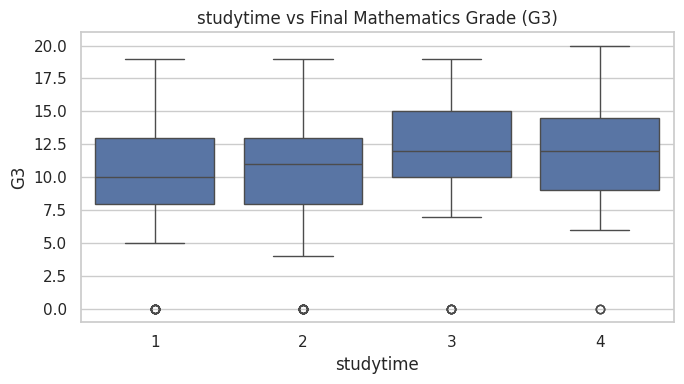

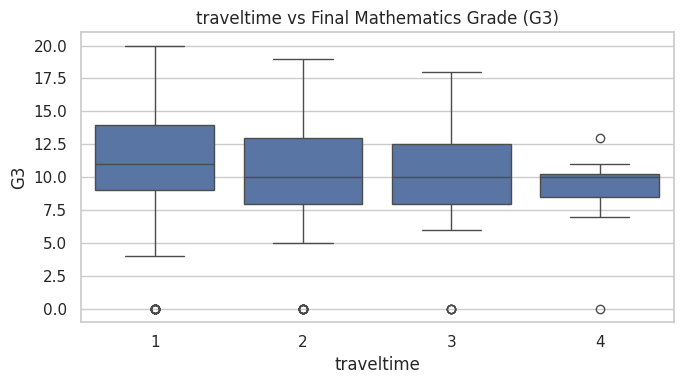

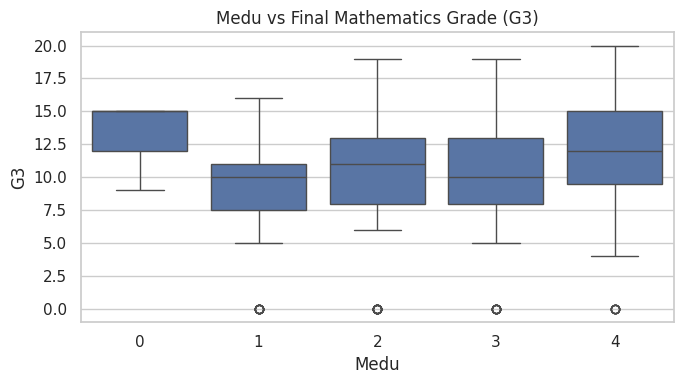

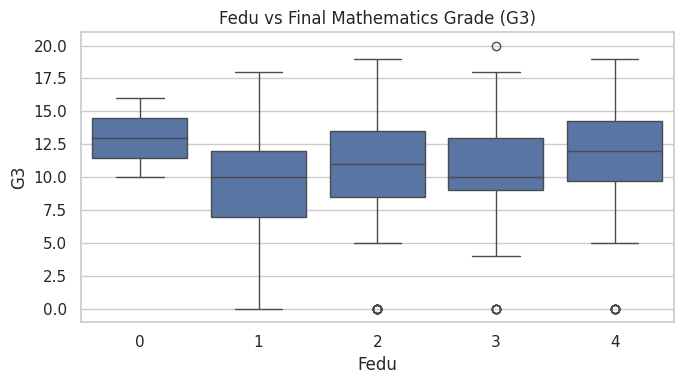

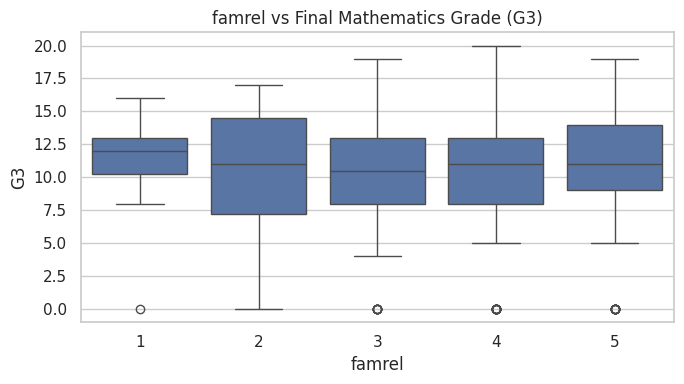

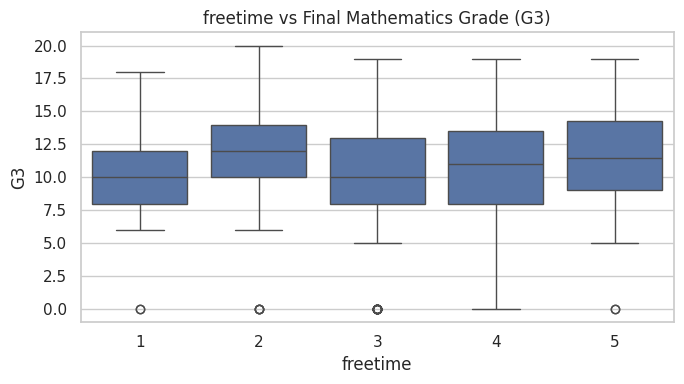

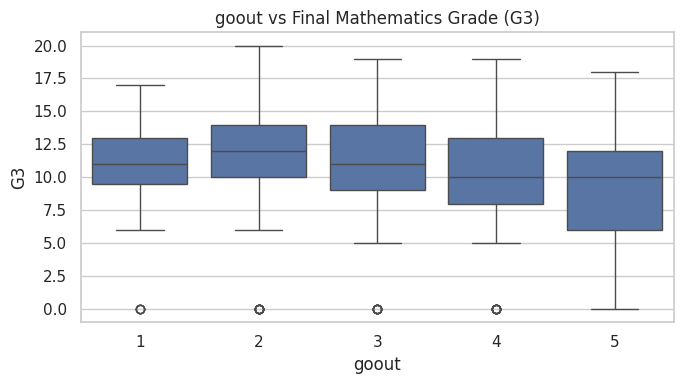

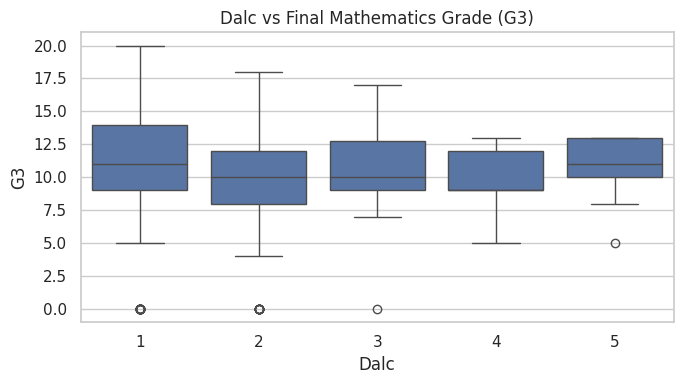

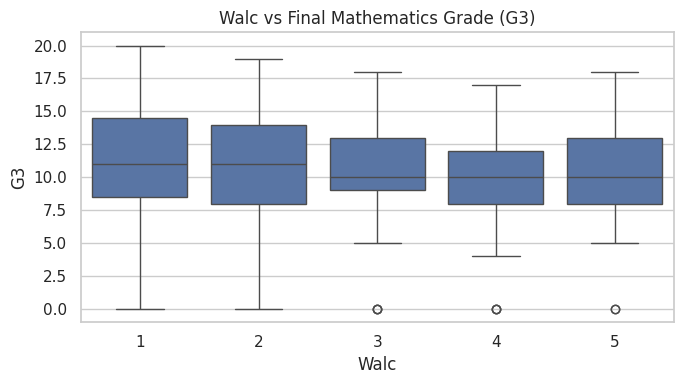

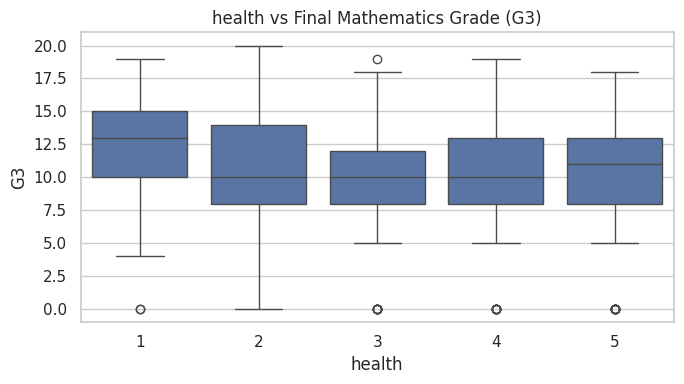

In [22]:
# ============================================================
# 21. Boxplots for important ordinal/numeric variables vs G3
# ============================================================
ordered_features = [
    "failures", "studytime", "traveltime",
    "Medu", "Fedu", "famrel", "freetime",
    "goout", "Dalc", "Walc", "health"
]

for col in ordered_features:
    if col in df.columns:
        plt.figure(figsize=(7, 4))
        sns.boxplot(data=df, x=col, y="G3")
        plt.title(f"{col} vs Final Mathematics Grade (G3)")
        plt.tight_layout()
        plt.show()

### Interpretation principle

These plots help identify **association patterns** such as:

- whether more previous failures correspond to lower final grades;
- whether study time categories differ in final performance;
- whether parental education appears related to G3;
- whether health, social activity, or travel time show visible group differences.

A visible difference is not evidence that a variable causes academic performance to change.

# 9. Bivariate EDA — categorical variables versus G3

For categorical variables, compare the distribution of `G3` across groups. We also check sample sizes because a category with very few students can produce unstable-looking differences.

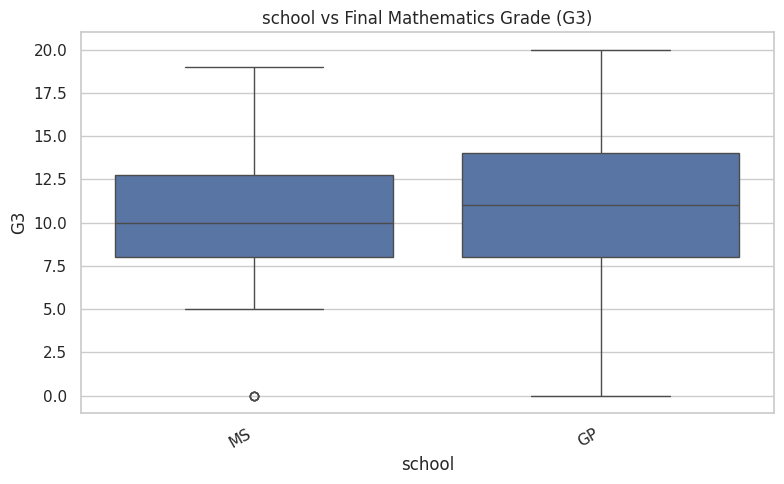

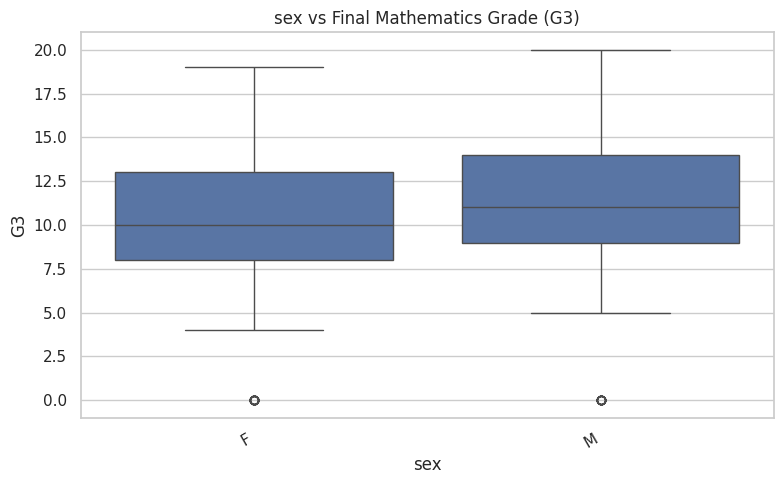

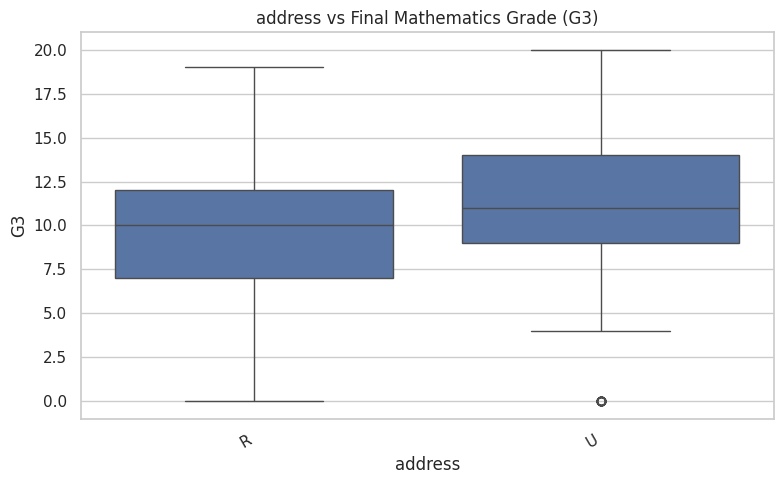

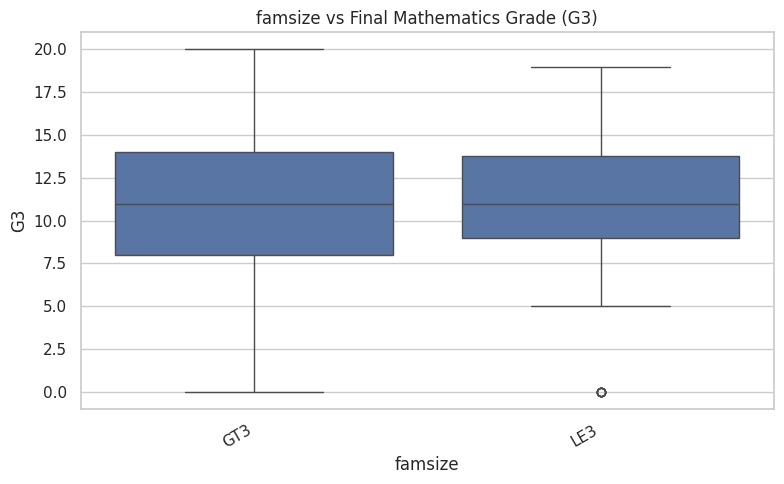

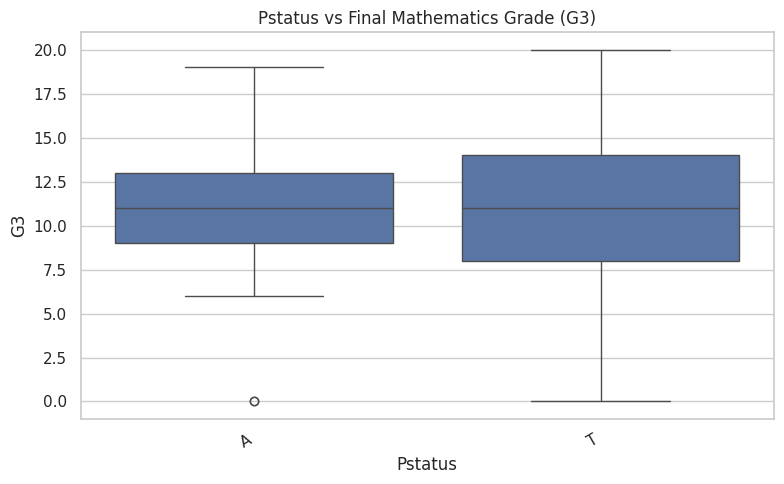

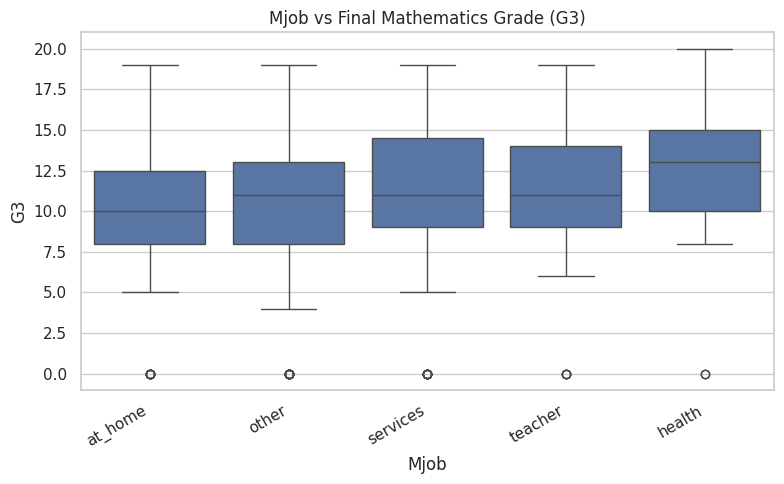

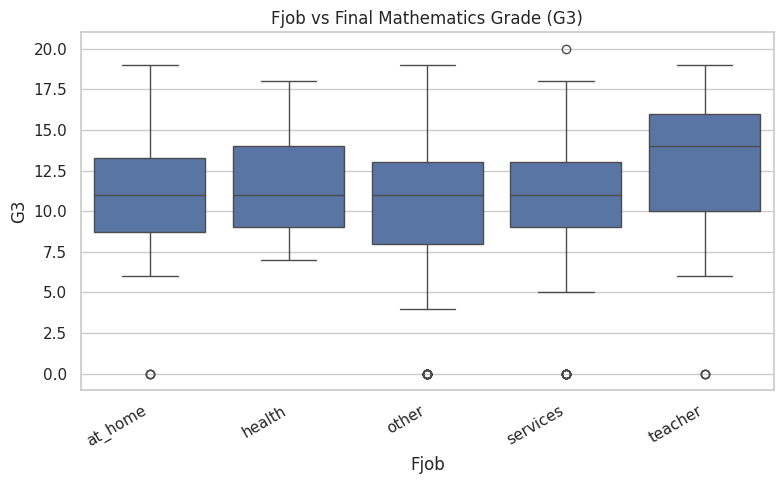

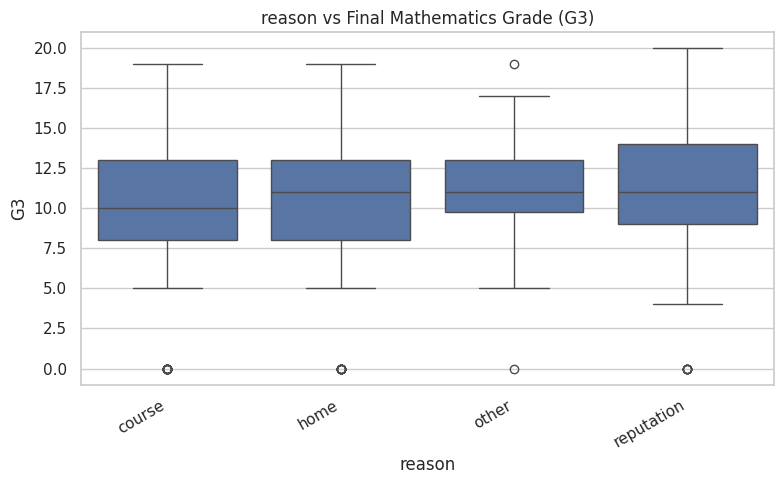

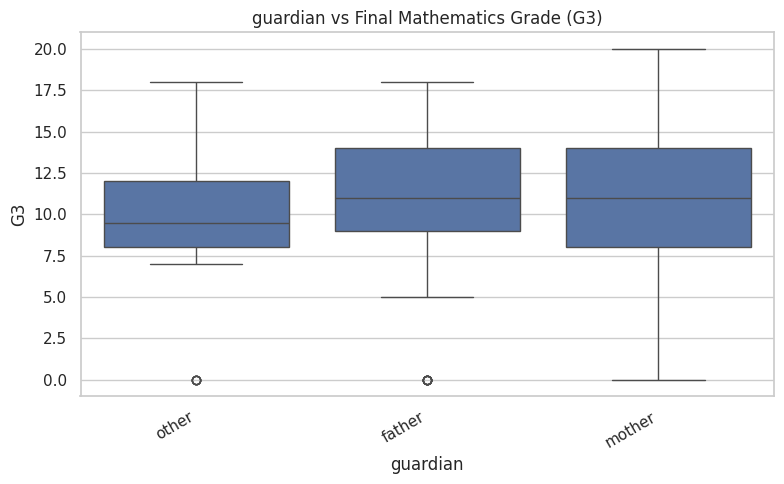

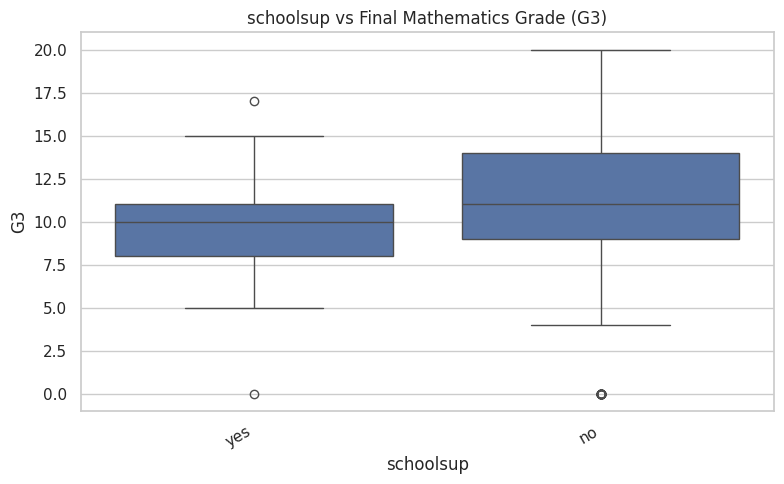

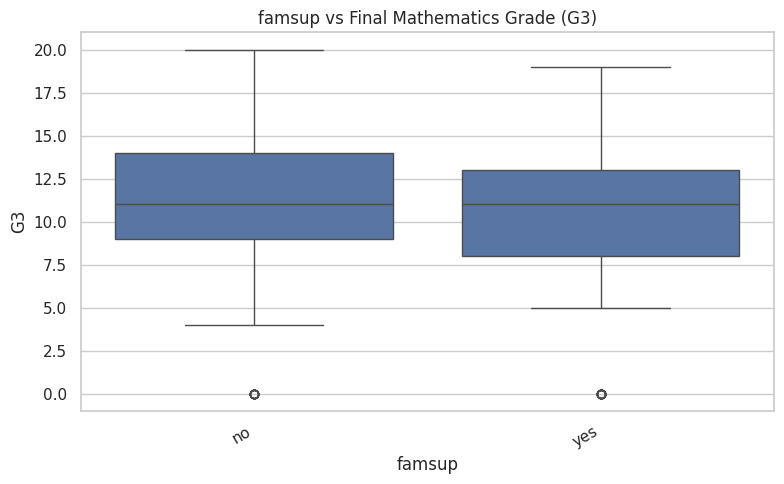

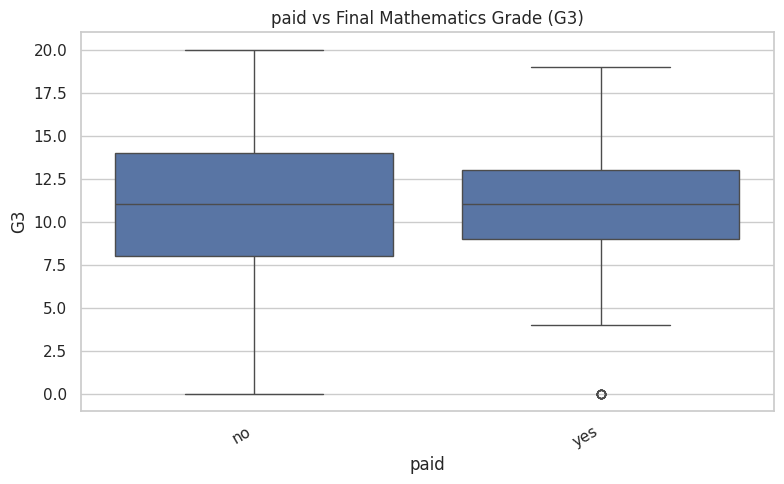

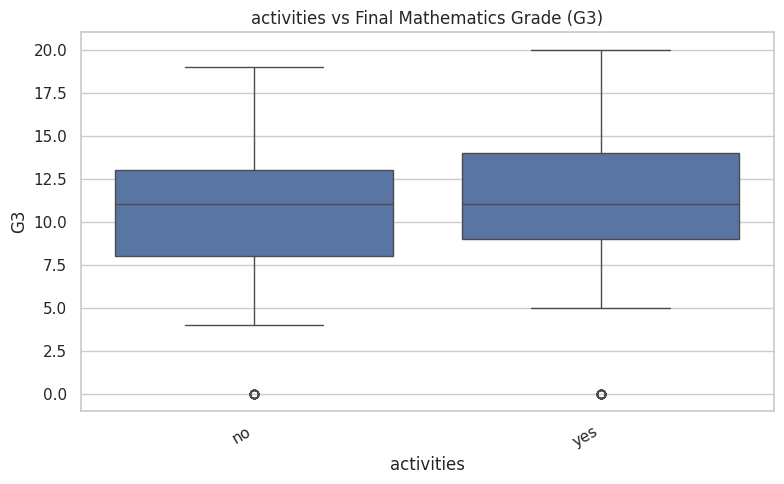

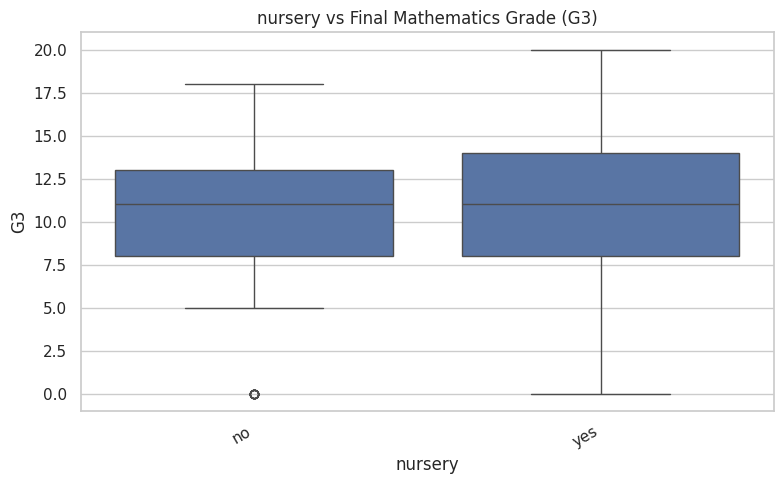

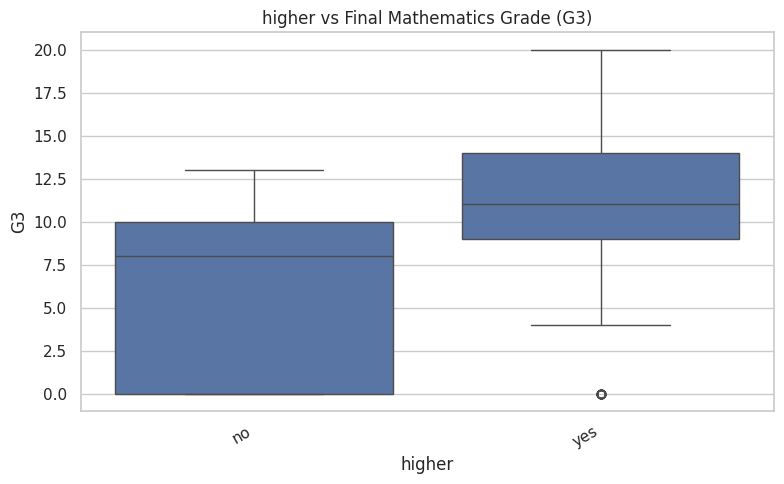

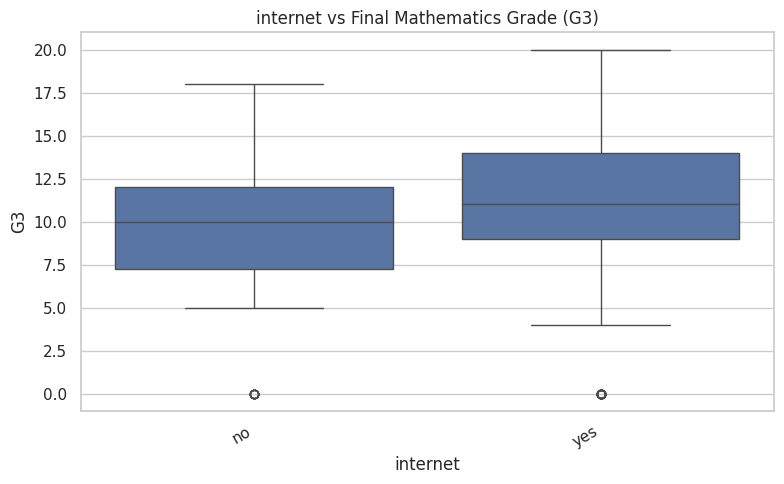

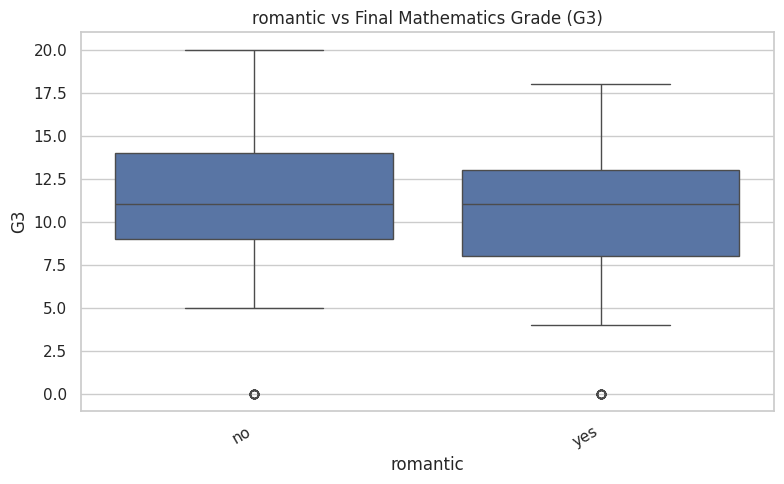

In [23]:
# ============================================================
# 22. Categorical groups versus G3
# ============================================================
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    order = df.groupby(col)["G3"].median().sort_values().index
    sns.boxplot(data=df, x=col, y="G3", order=order)
    plt.title(f"{col} vs Final Mathematics Grade (G3)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

In [24]:
# ============================================================
# 23. Grouped G3 summaries for categorical variables
# ============================================================
for col in categorical_cols:
    summary = (
        df.groupby(col)["G3"]
          .agg(["count", "mean", "median", "std"])
          .sort_values("mean")
          .round(2)
    )
    print(f"\n--- {col} ---")
    print(summary)


--- school ---
        count   mean  median   std
school                            
MS         46   9.85    10.0  4.24
GP        349  10.49    11.0  4.63

--- sex ---
     count   mean  median   std
sex                            
F      208   9.97    10.0  4.62
M      187  10.91    11.0  4.50

--- address ---
         count   mean  median   std
address                            
R           88   9.51    10.0  4.56
U          307  10.67    11.0  4.56

--- famsize ---
         count   mean  median   std
famsize                            
GT3        281  10.18    11.0  4.70
LE3        114  11.00    11.0  4.23

--- Pstatus ---
         count   mean  median   std
Pstatus                            
T          354  10.32    11.0  4.61
A           41  11.20    11.0  4.29

--- Mjob ---
          count   mean  median   std
Mjob                                
at_home      59   9.15    10.0  4.73
other       141   9.82    11.0  4.36
services    103  11.02    11.0  4.76
teacher      58  11.0

### What this section contributes

This provides evidence about which student characteristics are associated with differences in final Mathematics performance. It also gives the model-development member candidates for later feature analysis.

Do not select features solely because a group mean looks different. Later feature selection should be performed using training data and validated appropriately.

# 10. At-Risk group EDA

After investigating the candidate threshold, we can create a **temporary EDA-only label** to compare the characteristics of At-Risk and Not-At-Risk students.

This is not the final preprocessing pipeline. It is used here to understand what the proposed business target looks like.

In [25]:
# ============================================================
# 24. Temporary EDA risk label using the candidate threshold
# ============================================================
RISK_THRESHOLD = 10

eda = df.copy()
eda["Risk_Status"] = np.where(
    eda["G3"] < RISK_THRESHOLD,
    "At Risk",
    "Not at Risk"
)

print(
    eda["Risk_Status"]
      .value_counts()
      .to_frame("count")
      .assign(percentage=lambda x: (x["count"] / len(eda) * 100).round(2))
)

             count  percentage
Risk_Status                   
Not at Risk    265       67.09
At Risk        130       32.91


                G1                  G2                  G3             
              mean median   std   mean median   std   mean median   std
Risk_Status                                                            
At Risk       7.76    8.0  1.70   6.82    8.0  2.71   5.38    7.0  3.65
Not at Risk  12.45   12.0  2.79  12.62   12.0  2.53  12.88   12.0  2.50


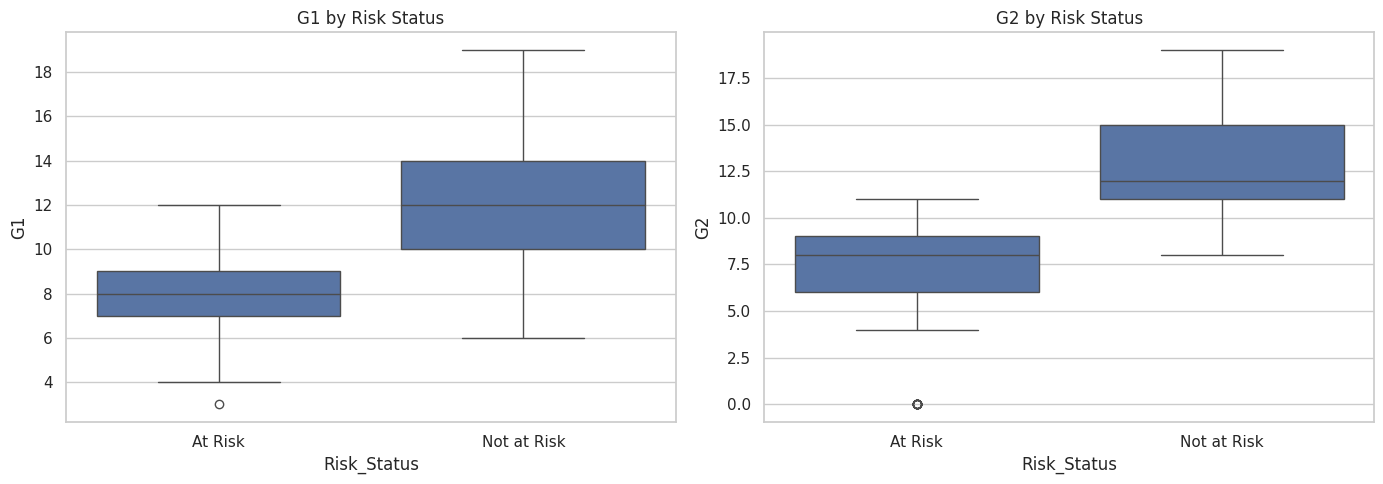

In [26]:
# ============================================================
# 25. Academic performance by risk group
# ============================================================
risk_grade_summary = (
    eda.groupby("Risk_Status")[["G1", "G2", "G3"]]
       .agg(["mean", "median", "std"])
       .round(2)
)

print(risk_grade_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=eda, x="Risk_Status", y="G1", ax=axes[0])
axes[0].set_title("G1 by Risk Status")

sns.boxplot(data=eda, x="Risk_Status", y="G2", ax=axes[1])
axes[1].set_title("G2 by Risk Status")

plt.tight_layout()
plt.show()

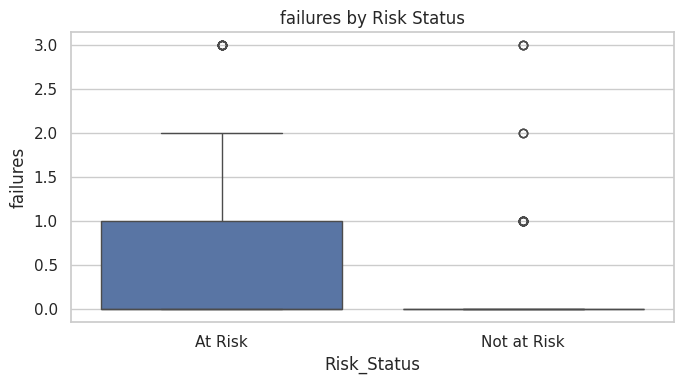

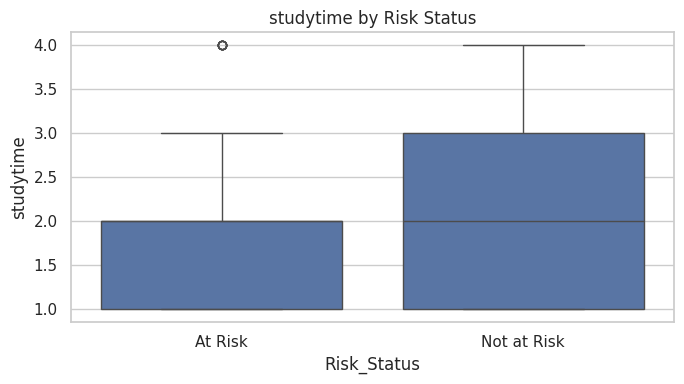

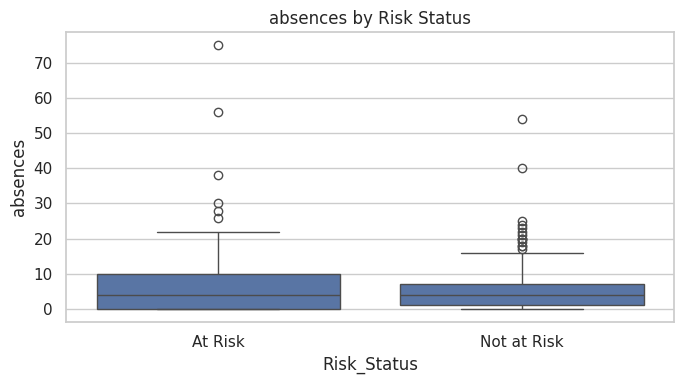

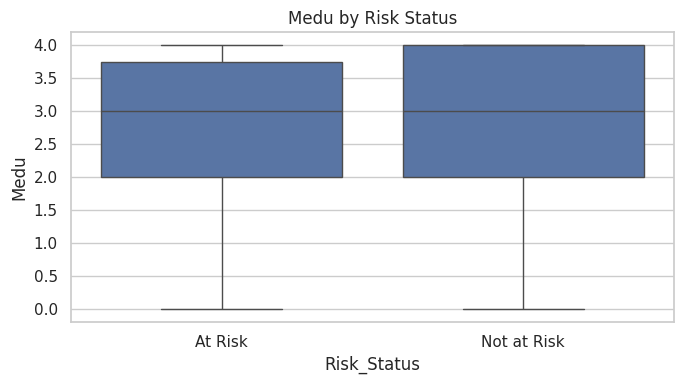

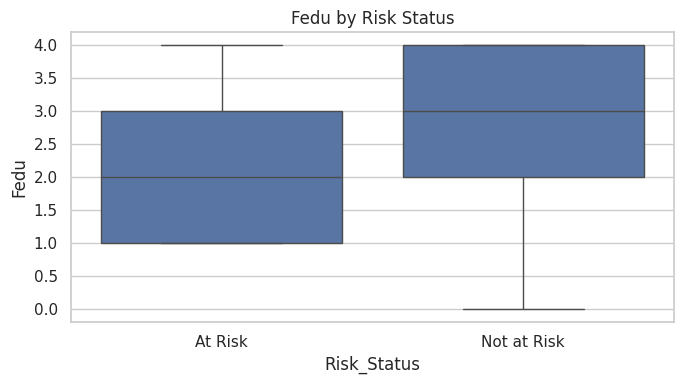

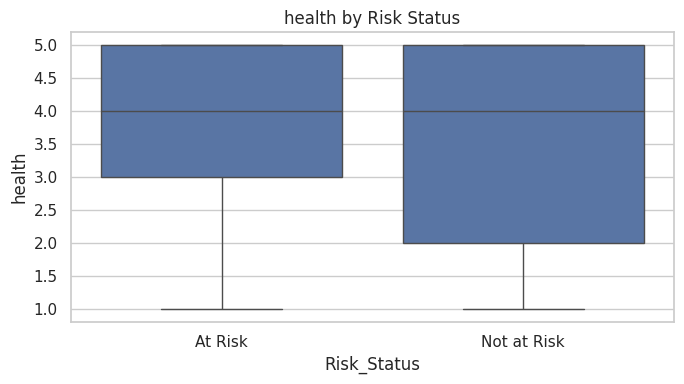

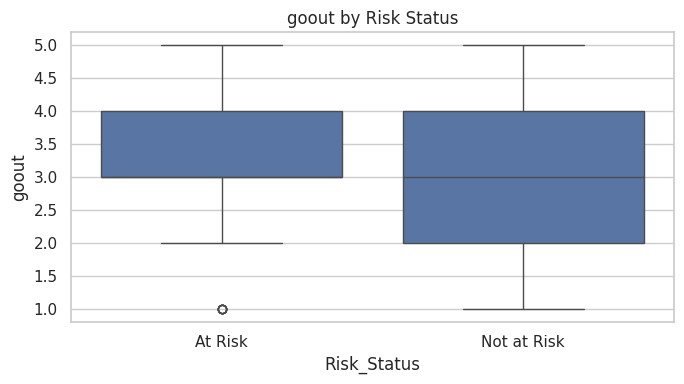

In [27]:
# ============================================================
# 26. Risk-group comparison for selected ordinal variables
# ============================================================
risk_features = [
    "failures", "studytime", "absences",
    "Medu", "Fedu", "health", "goout"
]

for col in risk_features:
    plt.figure(figsize=(7, 4))
    sns.boxplot(data=eda, x="Risk_Status", y=col)
    plt.title(f"{col} by Risk Status")
    plt.tight_layout()
    plt.show()


--- At-Risk rate by school ---
Risk_Status  At Risk  Not at Risk
school                           
MS             36.96        63.04
GP             32.38        67.62


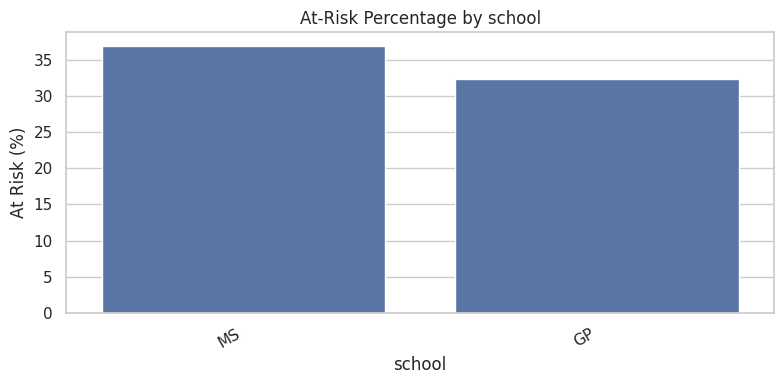


--- At-Risk rate by sex ---
Risk_Status  At Risk  Not at Risk
sex                              
F              36.06        63.94
M              29.41        70.59


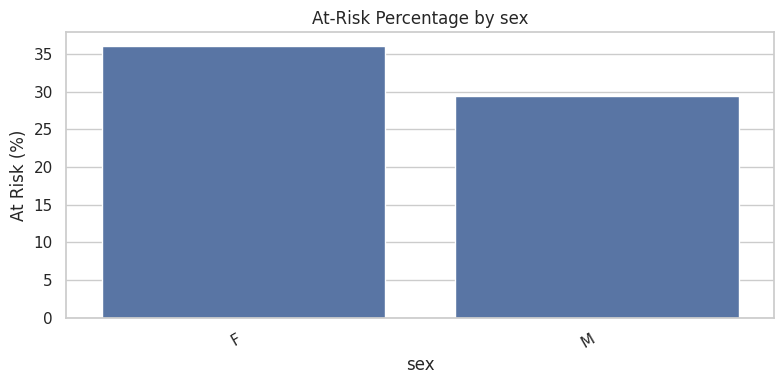


--- At-Risk rate by address ---
Risk_Status  At Risk  Not at Risk
address                          
R               37.5         62.5
U               31.6         68.4


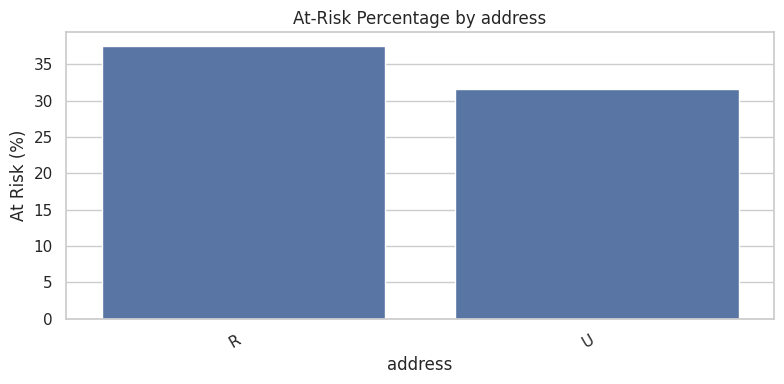


--- At-Risk rate by famsize ---
Risk_Status  At Risk  Not at Risk
famsize                          
GT3            34.16        65.84
LE3            29.82        70.18


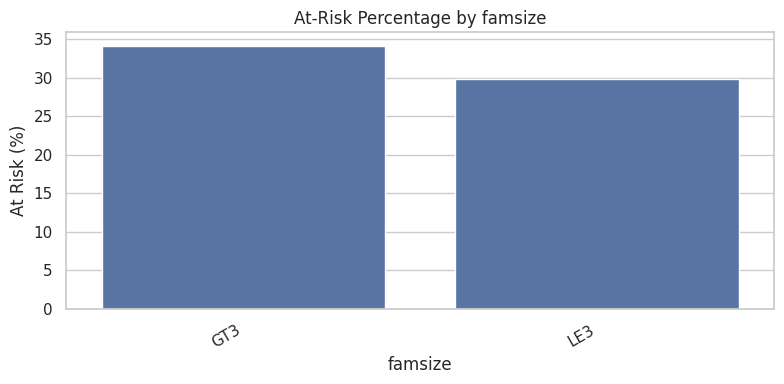


--- At-Risk rate by Pstatus ---
Risk_Status  At Risk  Not at Risk
Pstatus                          
T              33.62        66.38
A              26.83        73.17


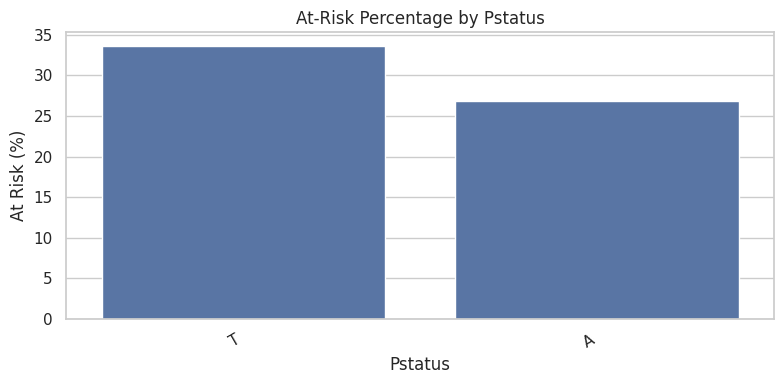


--- At-Risk rate by Mjob ---
Risk_Status  At Risk  Not at Risk
Mjob                             
other          37.59        62.41
at_home        37.29        62.71
teacher        32.76        67.24
services       28.16        71.84
health         20.59        79.41


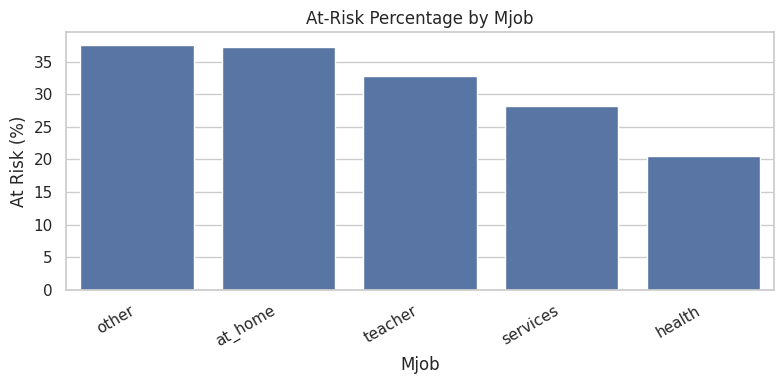


--- At-Risk rate by Fjob ---
Risk_Status  At Risk  Not at Risk
Fjob                             
at_home        40.00        60.00
services       36.04        63.96
health         33.33        66.67
other          31.80        68.20
teacher        24.14        75.86


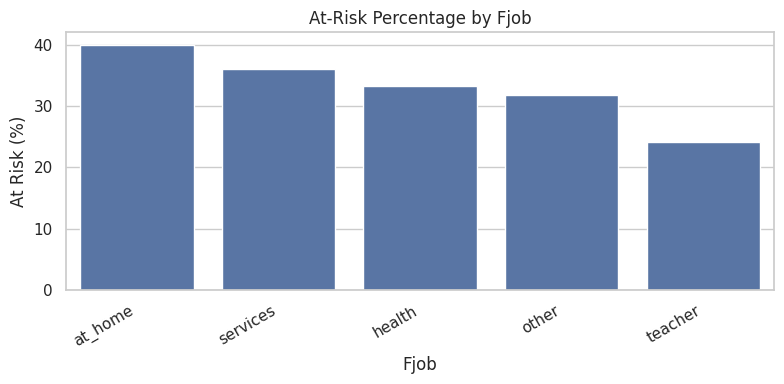


--- At-Risk rate by reason ---
Risk_Status  At Risk  Not at Risk
reason                           
course         38.62        61.38
home           33.03        66.97
reputation     27.62        72.38
other          25.00        75.00


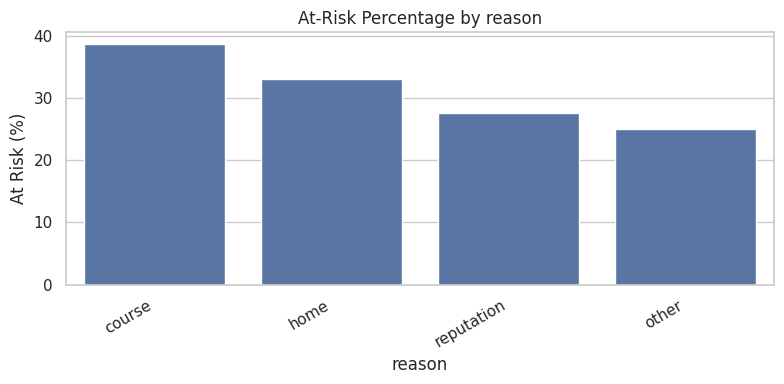


--- At-Risk rate by guardian ---
Risk_Status  At Risk  Not at Risk
guardian                         
other          50.00        50.00
mother         32.60        67.40
father         27.78        72.22


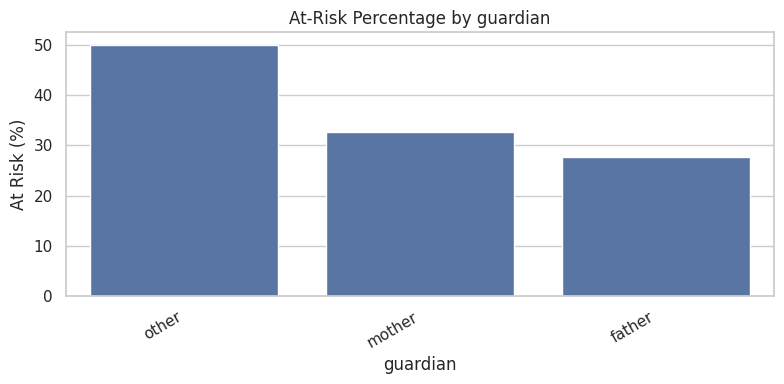


--- At-Risk rate by schoolsup ---
Risk_Status  At Risk  Not at Risk
schoolsup                        
yes             45.1         54.9
no              31.1         68.9


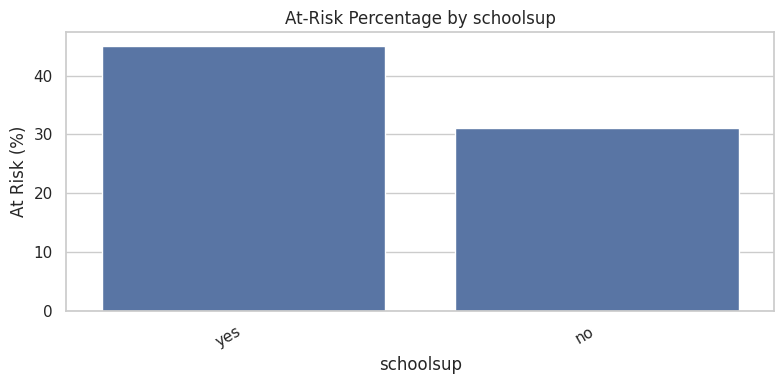


--- At-Risk rate by famsup ---
Risk_Status  At Risk  Not at Risk
famsup                           
yes            35.12        64.88
no             29.41        70.59


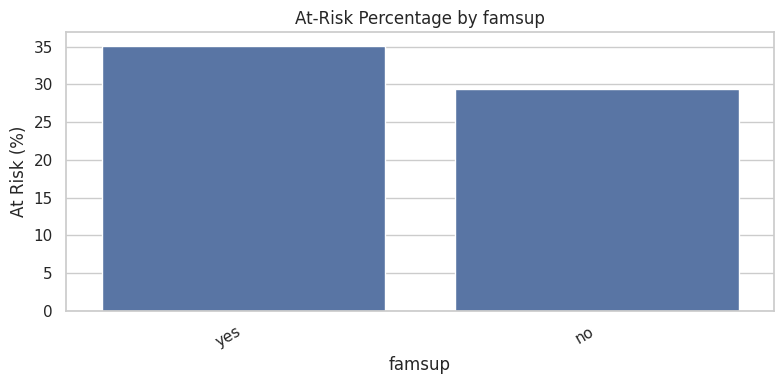


--- At-Risk rate by paid ---
Risk_Status  At Risk  Not at Risk
paid                             
no             36.92        63.08
yes            28.18        71.82


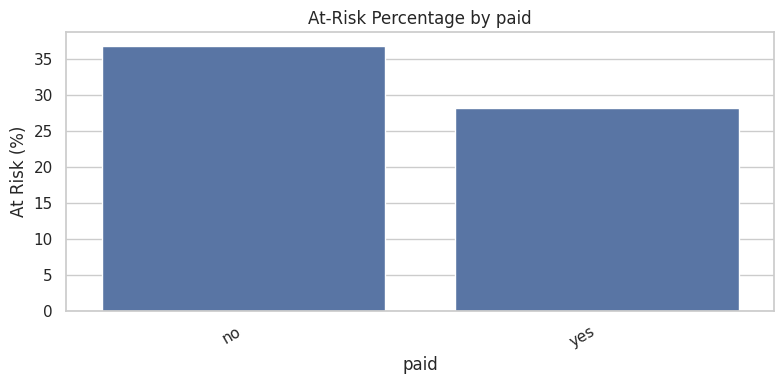


--- At-Risk rate by activities ---
Risk_Status  At Risk  Not at Risk
activities                       
no             33.51        66.49
yes            32.34        67.66


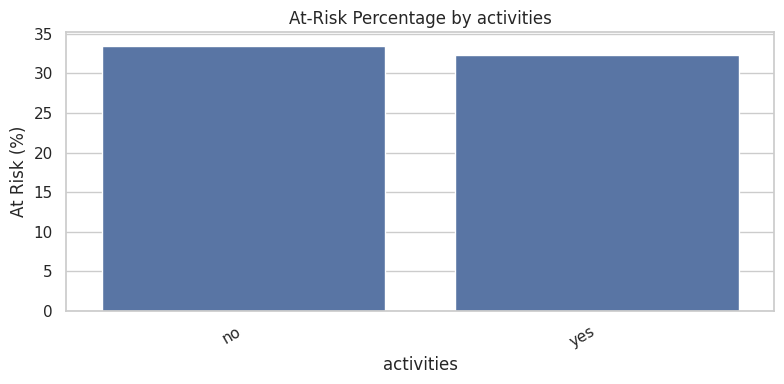


--- At-Risk rate by nursery ---
Risk_Status  At Risk  Not at Risk
nursery                          
yes            33.12        66.88
no             32.10        67.90


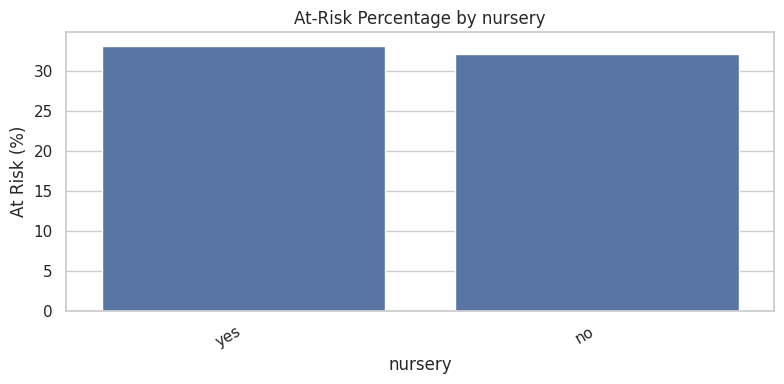


--- At-Risk rate by higher ---
Risk_Status  At Risk  Not at Risk
higher                           
no              65.0         35.0
yes             31.2         68.8


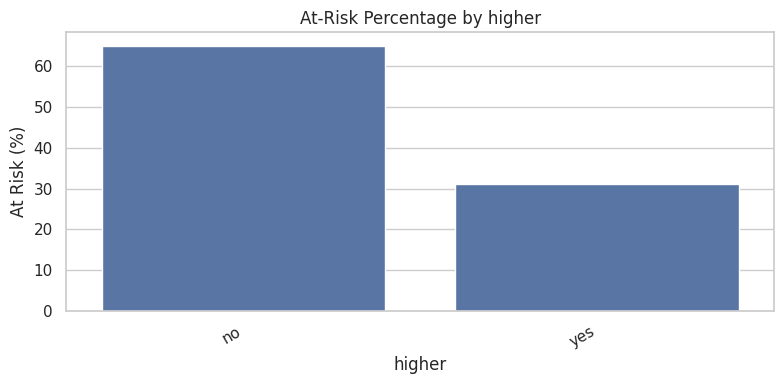


--- At-Risk rate by internet ---
Risk_Status  At Risk  Not at Risk
internet                         
no             39.39        60.61
yes            31.61        68.39


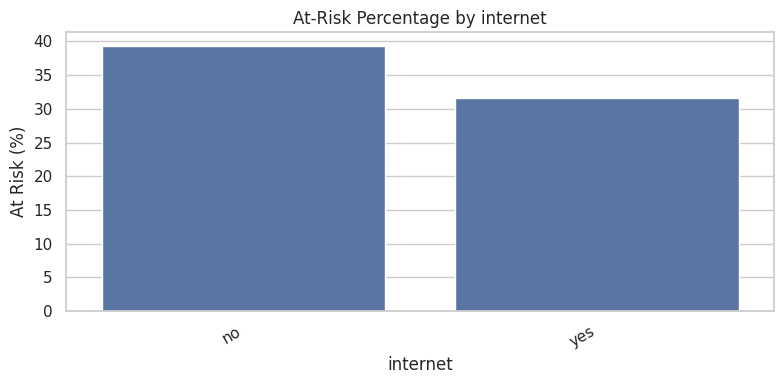


--- At-Risk rate by romantic ---
Risk_Status  At Risk  Not at Risk
romantic                         
yes            39.39        60.61
no             29.66        70.34


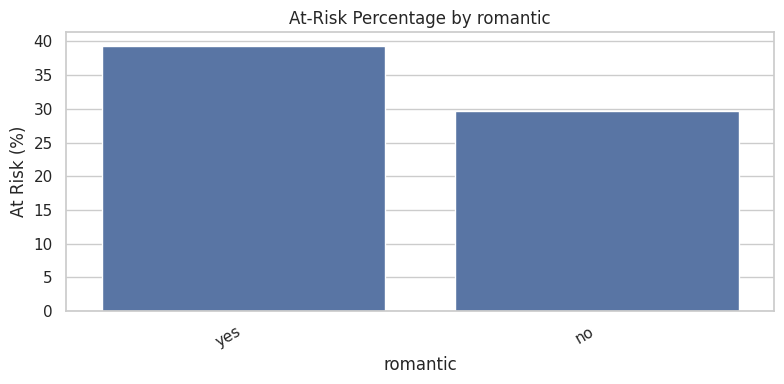

In [28]:
# ============================================================
# 27. Risk rate by categorical feature
# ============================================================
for col in categorical_cols:
    risk_rate = (
        pd.crosstab(
            eda[col],
            eda["Risk_Status"],
            normalize="index"
        )
        .mul(100)
        .round(2)
    )

    if "At Risk" in risk_rate.columns:
        risk_rate = risk_rate.sort_values("At Risk", ascending=False)

    print(f"\n--- At-Risk rate by {col} ---")
    print(risk_rate)

    if "At Risk" in risk_rate.columns:
        plt.figure(figsize=(8, 4))
        sns.barplot(x=risk_rate.index, y=risk_rate["At Risk"].values)
        plt.title(f"At-Risk Percentage by {col}")
        plt.ylabel("At Risk (%)")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

### Why this is useful

The At-Risk comparison converts general EDA into business-relevant evidence. It helps answer:

> "What characteristics appear more common among students who ultimately fall below the candidate final-grade threshold?"

This supports later feature analysis, but it should not be interpreted as causal evidence.

# 11. Relationship between previous performance and risk

Because `G1` and `G2` are available before `G3`, it is particularly useful to examine whether combinations of earlier grades reveal different risk patterns.

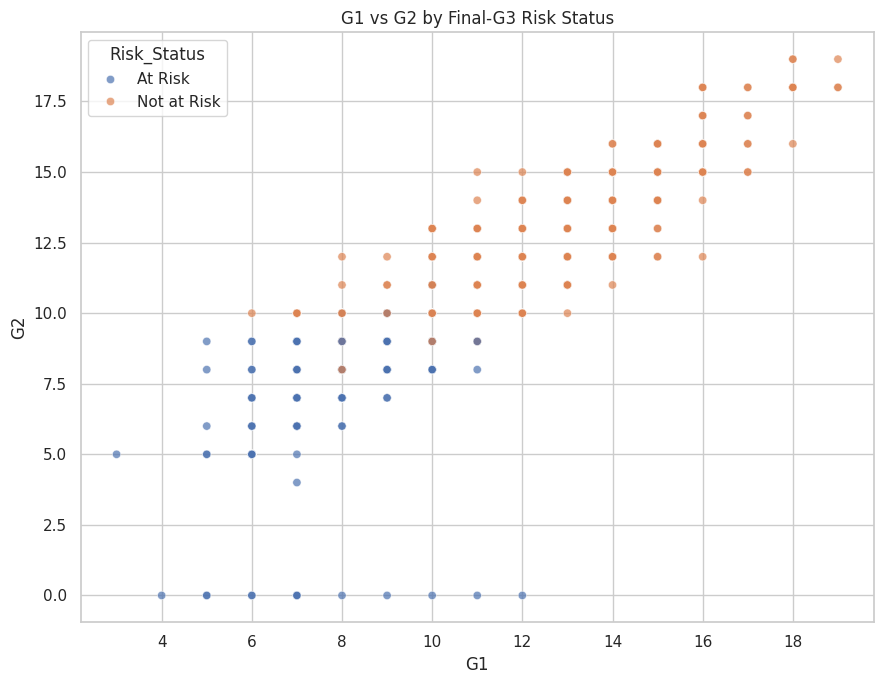

In [29]:
# ============================================================
# 28. G1 vs G2 coloured by EDA risk status
# ============================================================
plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=eda,
    x="G1",
    y="G2",
    hue="Risk_Status",
    alpha=0.7
)
plt.title("G1 vs G2 by Final-G3 Risk Status")
plt.tight_layout()
plt.show()

                    count   mean   std   min  25%   50%   75%   max
G1                  395.0  10.91  3.32   3.0  8.0  11.0  13.0  19.0
G2                  395.0  10.71  3.76   0.0  9.0  11.0  13.0  19.0
previous_grade_avg  395.0  10.81  3.41   2.0  8.5  11.0  13.0  19.0
grade_change        395.0  -0.19  1.97 -12.0 -1.0   0.0   1.0   4.0
G3                  395.0  10.42  4.58   0.0  8.0  11.0  14.0  20.0


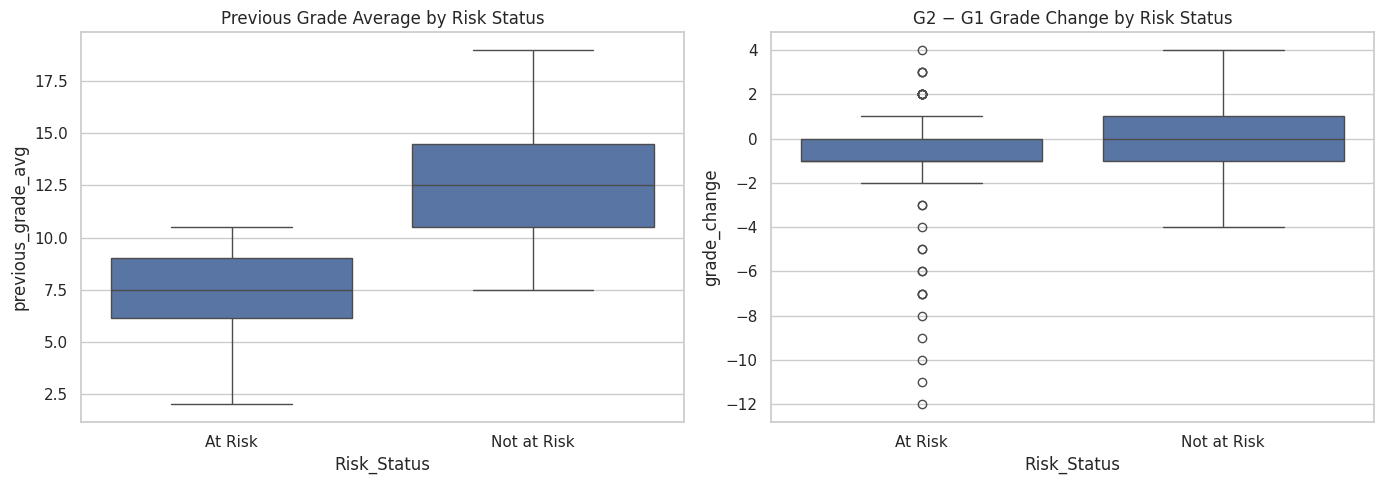

In [30]:
# ============================================================
# 29. Previous-grade average and grade trajectory
#     These are EDA-derived variables, not yet a final feature set.
# ============================================================
eda["previous_grade_avg"] = (eda["G1"] + eda["G2"]) / 2
eda["grade_change"] = eda["G2"] - eda["G1"]

print(
    eda[["G1", "G2", "previous_grade_avg", "grade_change", "G3"]]
    .describe()
    .T.round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=eda, x="Risk_Status", y="previous_grade_avg", ax=axes[0])
axes[0].set_title("Previous Grade Average by Risk Status")

sns.boxplot(data=eda, x="Risk_Status", y="grade_change", ax=axes[1])
axes[1].set_title("G2 − G1 Grade Change by Risk Status")

plt.tight_layout()
plt.show()

### Feature-engineering insight for the next stage

Two domain-motivated derived quantities are worth testing downstream:

- **Previous-grade average:** overall prior Mathematics performance.
- **Grade change:** whether the student improved or declined from G1 to G2.

These features are not automatically superior to G1 and G2. They should be tested using cross-validation by the modelling member. Because they are mathematically derived from G1/G2, multicollinearity and redundancy should also be considered.

# 12. Multivariate EDA

A correlation heatmap provides a compact overview of relationships among numeric/ordinal variables. It is useful for detecting redundancy and groups of strongly related variables.

Correlation does **not** establish causality.

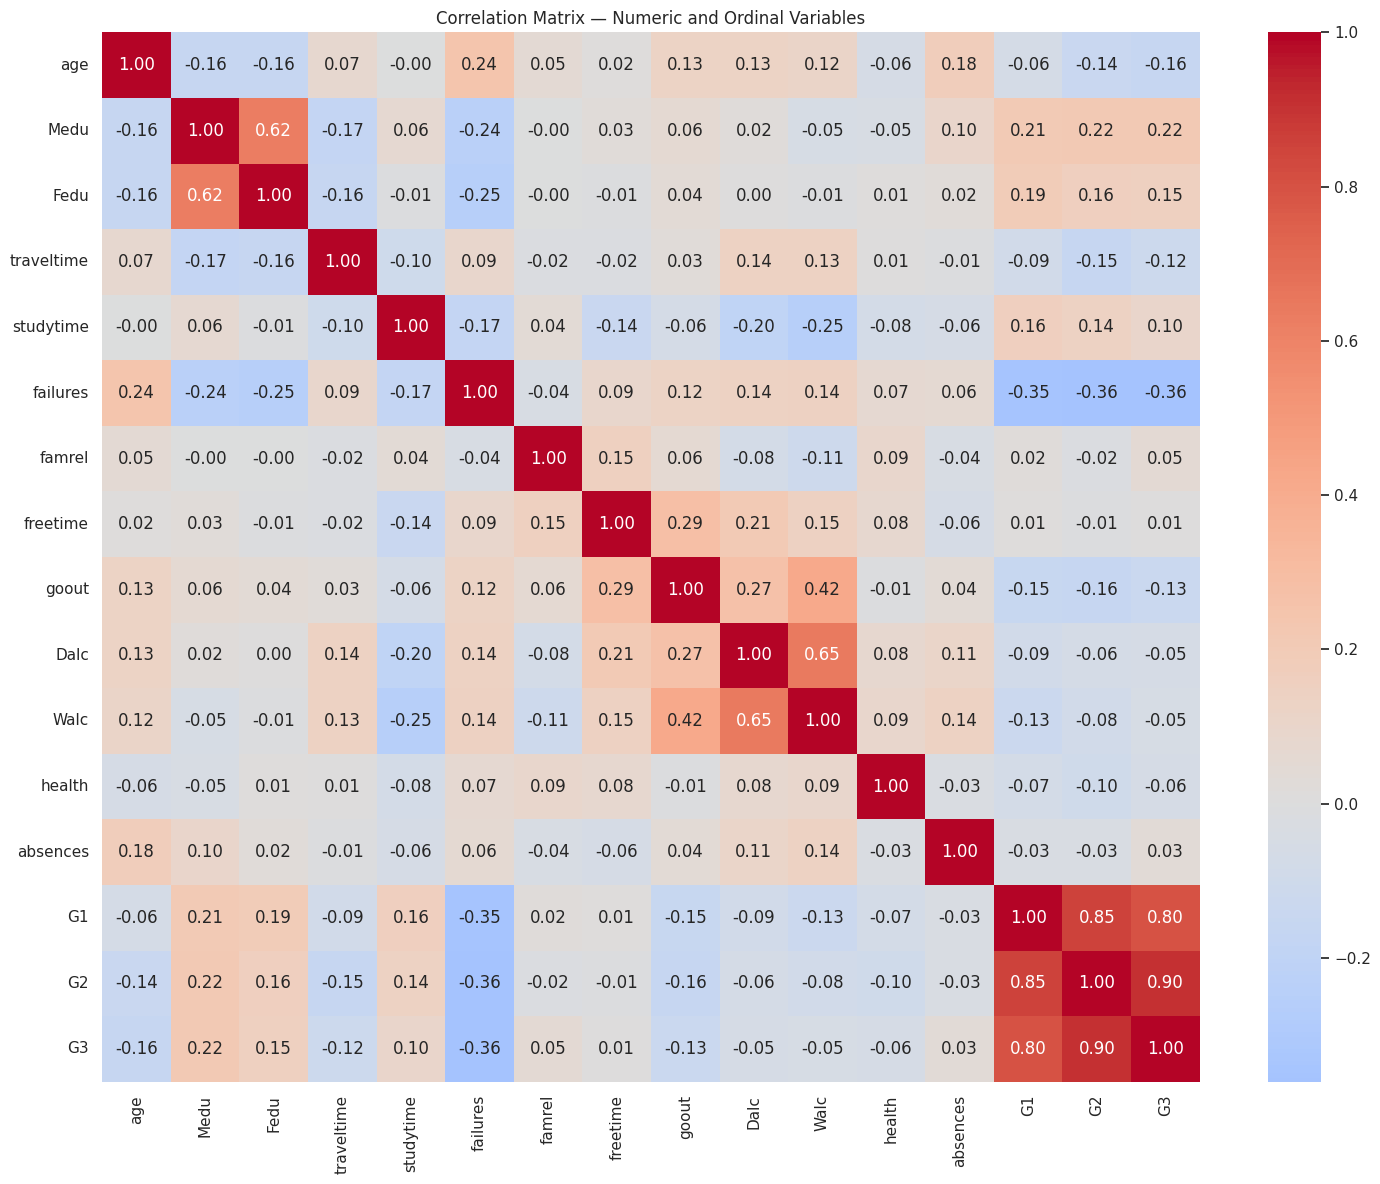

In [37]:
# ============================================================
# 30. Full numeric/ordinal correlation matrix
# ============================================================
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(15, 12))
sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Correlation Matrix — Numeric and Ordinal Variables")
plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# 31. Strongest absolute correlations among predictors
#     Exclude G3 because it is the outcome.
# ============================================================
predictor_numeric = numeric_df.drop(columns=["G3"])

corr_matrix = predictor_numeric.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

strong_pairs = (
    upper.stack()
         .sort_values(ascending=False)
         .to_frame("absolute_correlation")
)

print(strong_pairs.head(20).round(3))

                      absolute_correlation
G1        G2                         0.852
Dalc      Walc                       0.648
Medu      Fedu                       0.623
goout     Walc                       0.420
failures  G2                         0.356
          G1                         0.355
freetime  goout                      0.285
goout     Dalc                       0.267
studytime Walc                       0.254
Fedu      failures                   0.250
age       failures                   0.244
Medu      failures                   0.237
          G2                         0.216
freetime  Dalc                       0.209
Medu      G1                         0.205
studytime Dalc                       0.196
Fedu      G1                         0.190
age       absences                   0.175
studytime failures                   0.174
Medu      traveltime                 0.172


### Why this matters downstream

Strongly related predictors may carry overlapping information. This does not mean one should automatically be deleted. The modelling team can compare models and use feature-selection methods where appropriate.

For tree-based models, correlated variables are often less problematic for prediction than for coefficient interpretation. For linear models, correlated predictors can make coefficient estimates harder to interpret.

# 13. Outlier and distribution investigation

Outlier analysis is descriptive here. We use IQR-based counts to identify observations that deserve inspection; we do **not** automatically remove them.

In [33]:
# ============================================================
# 32. IQR-based outlier counts
# ============================================================
outlier_rows = []

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)

    outlier_rows.append({
        "variable": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
        "outlier_%": round(mask.mean() * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_rows).sort_values(
    "outlier_%", ascending=False
)

print(outlier_df.round(2))

      variable    Q1    Q3  IQR  lower_bound  upper_bound  outlier_count  \
5     failures   0.0   0.0  0.0          0.0          0.0             83   
4    studytime   1.0   2.0  1.0         -0.5          3.5             27   
6       famrel   4.0   5.0  1.0          2.5          6.5             26   
7     freetime   3.0   4.0  1.0          1.5          5.5             19   
9         Dalc   1.0   2.0  1.0         -0.5          3.5             18   
12    absences   0.0   8.0  8.0        -12.0         20.0             15   
14          G2   9.0  13.0  4.0          3.0         19.0             13   
3   traveltime   1.0   2.0  1.0         -0.5          3.5              8   
2         Fedu   2.0   3.0  1.0          0.5          4.5              2   
0          age  16.0  18.0  2.0         13.0         21.0              1   
1         Medu   2.0   4.0  2.0         -1.0          7.0              0   
8        goout   2.0   4.0  2.0         -1.0          7.0              0   
11      heal

### Outlier decision

An IQR flag means **unusual relative to the distribution**, not necessarily **wrong**.

For this educational dataset, an unusual absence count, for example, can be genuine. The appropriate downstream choice is therefore to investigate the observations and compare model performance with/without transformations rather than deleting all IQR-flagged rows.

# 14. Statistical association checks

EDA can use statistical tests as supporting evidence, but p-values should not replace effect sizes, plots, or domain reasoning.

We use:
- Pearson correlation for numeric/ordinal variables versus `G3`;
- point-biserial correlation for the temporary binary risk label versus numeric variables;
- chi-square tests for categorical variables versus the temporary risk label.

These are **exploratory** tests, so multiple-testing and sample-size issues must be kept in mind.

In [34]:
# ============================================================
# 33. Point-biserial association with temporary Risk_Status
# ============================================================
eda["Risk_binary"] = (eda["Risk_Status"] == "At Risk").astype(int)

pb_results = []
for col in numeric_cols:
    if col == "G3":
        continue

    r, p = pointbiserialr(eda["Risk_binary"], eda[col])
    pb_results.append({
        "variable": col,
        "point_biserial_r": r,
        "p_value": p
    })

pb_df = (
    pd.DataFrame(pb_results)
      .sort_values("point_biserial_r", key=lambda s: s.abs(), ascending=False)
)

print(pb_df.round(4))

      variable  point_biserial_r  p_value
14          G2           -0.7254   0.0000
13          G1           -0.6650   0.0000
5     failures            0.3377   0.0000
8        goout            0.1834   0.0002
0          age            0.1796   0.0003
1         Medu           -0.1154   0.0218
2         Fedu           -0.1081   0.0318
12    absences            0.0922   0.0670
4    studytime           -0.0746   0.1388
11      health            0.0657   0.1928
9         Dalc            0.0573   0.2555
6       famrel           -0.0467   0.3548
3   traveltime            0.0444   0.3783
10        Walc            0.0300   0.5528
7     freetime            0.0183   0.7166


In [35]:
# ============================================================
# 34. Chi-square association between categorical variables
#     and temporary Risk_Status
# ============================================================
chi_results = []

for col in categorical_cols:
    table = pd.crosstab(eda[col], eda["Risk_Status"])
    chi2, p, dof, expected = chi2_contingency(table)

    chi_results.append({
        "variable": col,
        "chi2": chi2,
        "p_value": p,
        "degrees_of_freedom": dof
    })

chi_df = (
    pd.DataFrame(chi_results)
      .sort_values("p_value")
)

print(chi_df.round(4))

      variable    chi2  p_value  degrees_of_freedom
14      higher  8.3531   0.0039                   1
16    romantic  3.3451   0.0674                   1
9    schoolsup  3.3307   0.0680                   1
8     guardian  5.3184   0.0700                   2
11        paid  3.0076   0.0829                   1
1          sex  1.6803   0.1949                   1
7       reason  4.4937   0.2128                   3
5         Mjob  5.3032   0.2576                   4
15    internet  1.1762   0.2781                   1
10      famsup  1.1386   0.2859                   1
2      address  0.8289   0.3626                   1
3      famsize  0.5090   0.4756                   1
4      Pstatus  0.4899   0.4840                   1
0       school  0.2063   0.6497                   1
6         Fjob  2.0804   0.7210                   4
12  activities  0.0195   0.8890                   1
13     nursery  0.0018   0.9665                   1


### Statistical-test caution

A statistically significant association can occur because of sample size and does not mean the feature is causally responsible for risk. Conversely, a non-significant result does not prove that a variable has no predictive value.

The modelling member should therefore use these results as **candidate evidence**, not as an automatic feature-selection rule.

# 15. EDA findings for hand-off

This section is intentionally designed as the hand-off from IT24100038's EDA work to the data-preparation and modelling members.

The project document says EDA findings should support later decisions about feature selection, risk-target creation, and interpretation. 

In [36]:
# ============================================================
# 35. Automatically generate key dataset facts
# ============================================================
print("========== EDA HAND-OFF SUMMARY ==========")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Missing cells: {int(df.isna().sum().sum())}")
print(f"Duplicate rows: {int(df.duplicated().sum())}")

print("\nG3 summary:")
print(df["G3"].describe().round(2))

print("\nCandidate threshold comparison:")
print(threshold_df)

print("\nStrongest numeric associations with G3:")
print(corr_with_g3.head(10).round(3).to_frame("correlation"))

print("\nMost skewed numeric variables:")
print(numeric_skew.head(10).round(3))

========== EDA HAND-OFF SUMMARY ==========
Rows: 395
Columns: 33
Missing cells: 0
Duplicate rows: 0

G3 summary:
count    395.00
mean      10.42
std        4.58
min        0.00
25%        8.00
50%       11.00
75%       14.00
max       20.00
Name: G3, dtype: float64

Candidate threshold comparison:
  Threshold  Threshold_value  At_Risk_n  At_Risk_%  Not_At_Risk_n  \
0    G3 < 8                8         70      17.72            325   
1    G3 < 9                9        102      25.82            293   
2   G3 < 10               10        130      32.91            265   
3   G3 < 11               11        186      47.09            209   
4   G3 < 12               12        233      58.99            162   

   Not_At_Risk_%  
0          82.28  
1          74.18  
2          67.09  
3          52.91  
4          41.01  

Strongest numeric associations with G3:
            correlation
G2                0.905
G1                0.801
failures         -0.360
Medu              0.217
age        

## Evidence-based conclusions to communicate

### 1. Dataset quality
- Report the actual missing-value and duplicate results from the executed notebook.
- Report any range-validation issues if found.
- Do not claim an issue exists when the data check does not show one.

### 2. Final-grade distribution
- `G3` is the final outcome and should be treated separately from predictors.
- Use its distribution to justify the candidate risk threshold.

### 3. Risk threshold
- Compare several candidate thresholds rather than choosing one without evidence.
- **G3 < 10** is a strong candidate for group consideration because it produces a substantial minority class in this dataset.
- The final threshold should be agreed with the EDA/business member and documented.

### 4. Earlier academic performance
- Examine the strength and shape of the relationships between `G1`, `G2`, and `G3`.
- If these relationships are strong, acknowledge that the eventual classifier may depend heavily on previous academic performance, which is also identified as a project limitation.

### 5. Behavioural/social/demographic variables
- Use group comparisons and association analysis to identify promising variables.
- Do not infer causation.
- Do not automatically discard variables solely because their univariate relationship is weak.

### 6. Outliers
- Flag unusual observations for inspection.
- Do not automatically delete legitimate extreme observations.

### 7. Feature-engineering candidates
- `previous_grade_avg = (G1 + G2) / 2`
- `grade_change = G2 - G1`
- Optionally investigate a transformation of `absences` downstream if its skewness materially affects a model.

### 8. Leakage
- `G3` is used to define the EDA risk outcome but must never be passed as a predictor to the final classification model.
- Any learned preprocessing, feature selection, or resampling must be performed later within training/CV pipelines.

These conclusions should feed the next member's **data preparation and target construction**, followed by the modelling member's classification experiments.

# 16. Final EDA checklist

Before submitting this EDA notebook, confirm that all of the following are present:

- [x] Dataset shape and structure
- [x] Data types
- [x] Missing-value analysis
- [x] Duplicate analysis
- [x] Unique-value/category inspection
- [x] Numeric descriptive statistics
- [x] Range validation
- [x] Skewness analysis
- [x] Histograms
- [x] Boxplots
- [x] Categorical frequency analysis
- [x] G1/G2/G3 distribution analysis
- [x] G1/G2/G3 correlation analysis
- [x] G1 and G2 relationship with G3
- [x] Numeric-variable relationship with G3
- [x] Categorical-variable relationship with G3
- [x] Candidate risk-threshold analysis
- [x] At-Risk vs Not-At-Risk comparisons
- [x] Correlation matrix
- [x] Outlier investigation
- [x] Statistical association checks as supporting evidence
- [x] Domain-driven feature-engineering candidates
- [x] Leakage warning and downstream hand-off
- [x] Final EDA findings summary

## Important boundary

This notebook is **EDA-focused**. It intentionally does not perform final model training, hyperparameter tuning, final test evaluation, or production preprocessing. Those belong to the other group responsibilities described in the project document.